# Part 2: Motor Imagery Classification

**Goal**: Classify left vs. right hand motor imagery using the PhysioNet EEG Motor Movement/Imagery Dataset.

**Core Methodology**: Band-pass filtering (mu/beta rhythms), Common Spatial Pattern (CSP) spatial filtering, and classification (LDA vs. SVM).

In [1]:
# Imports & Config
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

from sklearn.model_selection import train_test_split
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

mne.set_log_level("WARNING")

# Paths
DATA_DIR     = Path("../data/motor_imagery/eegmmidb")
RESULTS_DIR  = Path("../results/part2")
FIGURES_DIR  = Path("../figures/part2")
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Dataset Config
# Subject IDs present on disk — S001 through S109
SUBJECT_IDS = sorted([p.name for p in DATA_DIR.glob("S[0-9][0-9][0-9]") if p.is_dir()])

# Runs that contain LEFT vs RIGHT HAND IMAGERY (not movement)
#   Run 04 → Task 2: imagine left/right fist
#   Run 08 → Task 2 repeated
#   Run 12 → Task 2 repeated
IMAGERY_RUNS = [4, 8, 12]

# Event codes assigned by PhysioNet for imagery runs
#   T0 = rest baseline
#   T1 = left fist imagery
#   T2 = right fist imagery
EVENT_ID = {"rest": 1, "left": 2, "right": 3}  # MNE maps T0 → 1, T1 → 2, T2 → 3

SFREQ_EXPECTED = 160.0  # Hz — expected sampling rate for all subjects

print(f"Dataset root  : {DATA_DIR}")
print(f"Total Subjects: {len(SUBJECT_IDS)}")
print(f"Imagery runs  : {IMAGERY_RUNS}")

Dataset root  : ../data/motor_imagery/eegmmidb
Total Subjects: 109
Imagery runs  : [4, 8, 12]


## Data Audit

In [2]:
# Sanity Check (single subject → S001, Trial run = 4)
SANITY_SUBJECT = "S001"
SANITY_RUN     = 4

edf_path = DATA_DIR / SANITY_SUBJECT / f"{SANITY_SUBJECT}R{SANITY_RUN:02d}.edf"
print(f"Loading: {edf_path}\n")

raw_s001 = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)

# Channel names
print(f"Total channels : {len(raw_s001.ch_names)}")
print(f"Channel names  : {raw_s001.ch_names}")

Loading: ../data/motor_imagery/eegmmidb/S001/S001R04.edf

Total channels : 64
Channel names  : ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


`Notes`:
- The sample recording contains `64 EEG channels`, which matches the official PhysioNet setup and confirms that the full electrode montage is available for later CSP analysis.

In [3]:
# Sampling frequency
print(f"Sampling freq  : {raw_s001.info['sfreq']} Hz")
assert raw_s001.info['sfreq'] == SFREQ_EXPECTED, (
    f"Unexpected sfreq: {raw_s001.info['sfreq']} — expected {SFREQ_EXPECTED}"
)
print("✅ sfreq matches expected\n")

# Duration
duration_sec = raw_s001.times[-1]
print(f"Recording duration: {duration_sec:.1f} s ({duration_sec / 60:.2f} min)")

Sampling freq  : 160.0 Hz
✅ sfreq matches expected

Recording duration: 125.0 s (2.08 min)


`Notes`:
- The recording uses a sampling frequency of `160 Hz`, exactly as expected, so the data format is consistent with the official dataset and ready for filtering and epoching.
- The run duration is about `125 seconds`, which is close to the expected `2-minute task run`.

In [4]:
# Raw event annotations (what MNE reads from the EDF)
print("Raw annotations (first 10):")
print(raw_s001.annotations.to_data_frame().head(10))

Raw annotations (first 10):
                    onset  duration description
0 2009-08-12 16:15:00.000       4.2          T0
1 2009-08-12 16:15:04.200       4.1          T2
2 2009-08-12 16:15:08.300       4.2          T0
3 2009-08-12 16:15:12.500       4.1          T1
4 2009-08-12 16:15:16.600       4.2          T0
5 2009-08-12 16:15:20.800       4.1          T1
6 2009-08-12 16:15:24.900       4.2          T0
7 2009-08-12 16:15:29.100       4.1          T2
8 2009-08-12 16:15:33.200       4.2          T0
9 2009-08-12 16:15:37.400       4.1          T2


`Notes`:
- The raw annotations alternate between rest (T0) and imagery cues (T1/T2), which shows that the cue markers were read correctly from the EDF annotation channel.

In [5]:
# Convert annotations to MNE events and confirm T1/T2 mapping
raw_s001.load_data(verbose=False)
events, event_id_found = mne.events_from_annotations(raw_s001, verbose=False)

print(f"MNE event_id mapping found: {event_id_found}")
print(f"  → T1 maps to {event_id_found.get('T1', 'NOT FOUND')}  (expected 2 = left)")
print(f"  → T2 maps to {event_id_found.get('T2', 'NOT FOUND')}  (expected 3 = right)")

MNE event_id mapping found: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
  → T1 maps to 2  (expected 2 = left)
  → T2 maps to 3  (expected 3 = right)


`Notes`:
- The MNE event conversion worked correctly: T1 maps to the left-hand class and T2 maps to the right-hand class, so the event labels are ready for epoch creation.

In [6]:
# Count T1 and T2 events
left_code  = event_id_found.get("T1")
right_code = event_id_found.get("T2")

n_left  = (events[:, 2] == left_code).sum()
n_right = (events[:, 2] == right_code).sum()

print(f"T1 (left)  events: {n_left}")
print(f"T2 (right) events: {n_right}")
print(f"Total imagery events: {n_left + n_right}")

if n_left != n_right:
    print("⚠️ WARNING: trial counts are imbalanced in this run!")
else:
    print("✅ Trial counts are balanced")

T1 (left)  events: 8
T2 (right) events: 7
Total imagery events: 15
⚠️ WARNING: trial counts are imbalanced in this run!


`Notes`:
- In this single run, the class counts are slightly imbalanced (8 left vs 7 right), so class balance should be checked again after combining runs 4, 8, and 12 for each subject.

`Preprocessing note`: the channel names include trailing dots such as Fc2., Fc4., Fc6., C3.., Cz.., and O1... 
<br><br>
Need to clean and standardize these names early to make make channel selection and topographic plotting easier later.

In [7]:
# All-Participant Data Audit
audit_rows = []
total_subjects = len(SUBJECT_IDS)

for i, subject in enumerate(SUBJECT_IDS, 1):
    print(f"[{i}/{total_subjects}] Processing {subject}...")
    subject_totals = {
        "participant": subject,
        "total_left": 0,
        "total_right": 0,
        "total_trials": 0,
        "runs_read": 0,
        "sfreq": None,
        "notes": []
    }

    for run in IMAGERY_RUNS:
        edf_path = DATA_DIR / subject / f"{subject}R{run:02d}.edf"

        if not edf_path.exists():
            subject_totals["notes"].append(f"R{run:02d}: FILE MISSING")
            continue

        try:
            raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)

            if subject_totals["sfreq"] is None:
                subject_totals["sfreq"] = raw.info["sfreq"]
            
            # sfreq check
            if not np.isclose(raw.info["sfreq"], SFREQ_EXPECTED):
                subject_totals["notes"].append(
                    f"R{run:02d}: sfreq={raw.info['sfreq']} (expected {SFREQ_EXPECTED})"
                )

            # Strip trailing dots from channel names
            mne.rename_channels(raw.info, {ch: ch.rstrip(".") for ch in raw.ch_names})

            # Parse events from annotations
            events, event_id_found = mne.events_from_annotations(raw, verbose=False)

            left_code = event_id_found.get("T1")
            right_code = event_id_found.get("T2")

            n_left = int((events[:, 2] == left_code).sum()) if left_code is not None else 0
            n_right = int((events[:, 2] == right_code).sum()) if right_code is not None else 0

            if left_code is None:
                subject_totals["notes"].append(f"R{run:02d}: T1 (left) annotation missing")
            if right_code is None:
                subject_totals["notes"].append(f"R{run:02d}: T2 (right) annotation missing")

            subject_totals["total_left"] += n_left
            subject_totals["total_right"] += n_right
            subject_totals["total_trials"] += n_left + n_right
            subject_totals["runs_read"] += 1

        except Exception as e:
            subject_totals["notes"].append(f"R{run:02d}: ERROR — {str(e)[:60]}")

    subject_totals["notes"] = "; ".join(subject_totals["notes"]) if subject_totals["notes"] else "OK"
    audit_rows.append(subject_totals)

print(f"Audit complete: {len(audit_rows)} subjects processed.")

[1/109] Processing S001...
[2/109] Processing S002...
[3/109] Processing S003...
[4/109] Processing S004...
[5/109] Processing S005...
[6/109] Processing S006...
[7/109] Processing S007...
[8/109] Processing S008...
[9/109] Processing S009...
[10/109] Processing S010...
[11/109] Processing S011...
[12/109] Processing S012...
[13/109] Processing S013...
[14/109] Processing S014...
[15/109] Processing S015...
[16/109] Processing S016...
[17/109] Processing S017...
[18/109] Processing S018...
[19/109] Processing S019...
[20/109] Processing S020...
[21/109] Processing S021...
[22/109] Processing S022...
[23/109] Processing S023...
[24/109] Processing S024...
[25/109] Processing S025...
[26/109] Processing S026...
[27/109] Processing S027...
[28/109] Processing S028...
[29/109] Processing S029...
[30/109] Processing S030...
[31/109] Processing S031...
[32/109] Processing S032...
[33/109] Processing S033...
[34/109] Processing S034...
[35/109] Processing S035...
[36/109] Processing S036...
[

`Note`:<br>
During loading, we can see `RuntimeWarning: Limited 1 annotation(s)...`.

This simply means the metadata recorded the final "experiment end" event as lasting slightly longer than the actual EEG recording. MNE automatically truncates it to fit the data. 

Since we only care about the `T1` (left) and `T2` (right) imagination cues in the middle of the recording, this warning is harmless and we can safely ignore it.

In [8]:
# Audit Analysis
audit_df = pd.DataFrame(audit_rows)

# Basic diagnostics
audit_df["balanced_exact"] = audit_df["total_left"] == audit_df["total_right"]
audit_df["balance_diff"] = (audit_df["total_left"] - audit_df["total_right"]).abs()
audit_df["all_runs_ok"] = audit_df["runs_read"] == len(IMAGERY_RUNS)
audit_df["has_both_classes"] = (audit_df["total_left"] > 0) & (audit_df["total_right"] > 0)
audit_df["no_logged_issues"] = audit_df["notes"] == "OK"

# Final practical rule
audit_df["ready"] = (
    audit_df["all_runs_ok"] &
    audit_df["has_both_classes"] &
    audit_df["no_logged_issues"]
)

print(f"Subjects with all 3 runs OK: {audit_df['all_runs_ok'].sum()} / {len(audit_df)}")
print(f"Subjects with exact left/right balance: {audit_df['balanced_exact'].sum()} / {len(audit_df)}")
print(f"Subjects with both classes present: {audit_df['has_both_classes'].sum()} / {len(audit_df)}")
print(f"Subjects that are ready: {audit_df['ready'].sum()} / {len(audit_df)}\n")

# Show subjects that need review
problems = audit_df[~audit_df["ready"]]
if not problems.empty:
    print("=== Subjects Needing Review ===")
    print(
        problems[
            ["participant", "sfreq", "total_left", "total_right", "balance_diff", "runs_read", "notes"]
        ].to_string(index=False)
    )

# Save audit
audit_df.to_csv(RESULTS_DIR / "part2_data_audit.csv", index=False)

# Final clean list
FINAL_SUBJECTS = audit_df.loc[audit_df["ready"], "participant"].tolist()
print(f"\nFinal SUBJECT count: {len(FINAL_SUBJECTS)}")

Subjects with all 3 runs OK: 109 / 109
Subjects with exact left/right balance: 1 / 109
Subjects with both classes present: 109 / 109
Subjects that are ready: 106 / 109

=== Subjects Needing Review ===
participant  sfreq  total_left  total_right  balance_diff  runs_read                                                                                                   notes
       S088  128.0          29           28             1          3 R04: sfreq=128.0 (expected 160.0); R08: sfreq=128.0 (expected 160.0); R12: sfreq=128.0 (expected 160.0)
       S092  128.0          27           30             3          3 R04: sfreq=128.0 (expected 160.0); R08: sfreq=128.0 (expected 160.0); R12: sfreq=128.0 (expected 160.0)
       S100  128.0          18           18             0          3 R04: sfreq=128.0 (expected 160.0); R08: sfreq=128.0 (expected 160.0); R12: sfreq=128.0 (expected 160.0)

Final SUBJECT count: 106


`Notes`:
- All 109 participants were found and all three imagery runs loaded successfully.
- Every participant had both `T1` and `T2` imagery events, so no subject was missing an entire class.
- Only 3 participants (`S088`, `S092`, `S100`) were flagged because their runs were sampled at 128 Hz instead of the expected 160 Hz.
- Since the rest of the dataset uses the standard 64-channel motor imagery setup, these 3 subjects were excluded for now to keep preprocessing fully consistent across participants. 
- This leaves 106 final subjects for the first classification baseline.
- Exact left/right trial balance was rare, assuming this is not a major concern because both classes are still present for all usable subjects.

### Final dataset policy

Current audit outcome:
- 109 participants were found in total.
- 106 participants are clean at the expected sampling frequency.
- 3 participants (`S088`, `S092`, `S100`) were flagged because their runs use 128 Hz instead of 160 Hz.

For now, I will keep:
- a **clean pool** for stable baseline experiments, and
- a **flagged pool** for later resampling so the final version can remain task-compliant and include all participants.

In [9]:
# Expected problematic subjects from the audit
FLAGGED_SUBJECTS = {"S088", "S092", "S100"}

# Infer the participant column name
possible_id_cols = ["participant", "subject_id", "subject", "participant_id"]
id_col = next((c for c in possible_id_cols if c in audit_df.columns), None)

if id_col is None:
    raise ValueError(
        f"Could not find participant column. Available columns: {list(audit_df.columns)}"
    )

# Build pools
all_subjects = sorted(audit_df[id_col].astype(str).unique().tolist())
clean_subjects = [sid for sid in all_subjects if sid not in FLAGGED_SUBJECTS]
flagged_subjects = [sid for sid in all_subjects if sid in FLAGGED_SUBJECTS]

# Summary table
dataset_policy_df = pd.DataFrame({
    "group": [
        "All participants found",
        "Clean participants (160 Hz)",
        "Flagged participants (128 Hz)",
    ],
    "count": [
        len(all_subjects),
        len(clean_subjects),
        len(flagged_subjects),
    ],
    "subjects": [
        ", ".join(all_subjects[:8]) + (" ..." if len(all_subjects) > 8 else ""),
        ", ".join(clean_subjects[:8]) + (" ..." if len(clean_subjects) > 8 else ""),
        ", ".join(flagged_subjects) if flagged_subjects else "None",
    ]
})

print("All subjects:", len(all_subjects))
print("Clean subjects:", len(clean_subjects))
print("Flagged subjects:", len(flagged_subjects))
print("\nFlagged list:", flagged_subjects)

display(dataset_policy_df)

ALL_SUBJECTS = all_subjects
CLEAN_SUBJECTS = clean_subjects
FLAGGED_SUBJECTS = flagged_subjects

All subjects: 109
Clean subjects: 106
Flagged subjects: 3

Flagged list: ['S088', 'S092', 'S100']


,group,count,subjects
0,All participants found,109,"S001, S002, S003, S004, S005, S006, S007, S008..."
1,Clean participants (160 Hz),106,"S001, S002, S003, S004, S005, S006, S007, S008..."
2,Flagged participants (128 Hz),3,"S088, S092, S100"


## Motor imagery band selection and PSD check

I will use an initial band-pass range of **8–30 Hz** for motor imagery preprocessing.

Why this range:
- It captures the **mu rhythm** (about 8–13 Hz) and the **beta rhythm** (roughly 13–30 Hz), which are the main frequency bands associated with motor imagery.
- [Ramoser et al.](https://ieeexplore.ieee.org/document/895946) used **8–30 Hz** before CSP and justified it as a band that covers the alpha/mu and beta components most relevant for movement classification.

`Note`:
- This PSD step is only for **signal inspection and parameter justification**.
- Later, in the classification pipeline, filtering will be handled in a train/test-safe way to avoid leakage.

Chosen band: (8.0, 30.0) Hz
Sampling frequency: 160.0
Number of EEG channels: 64


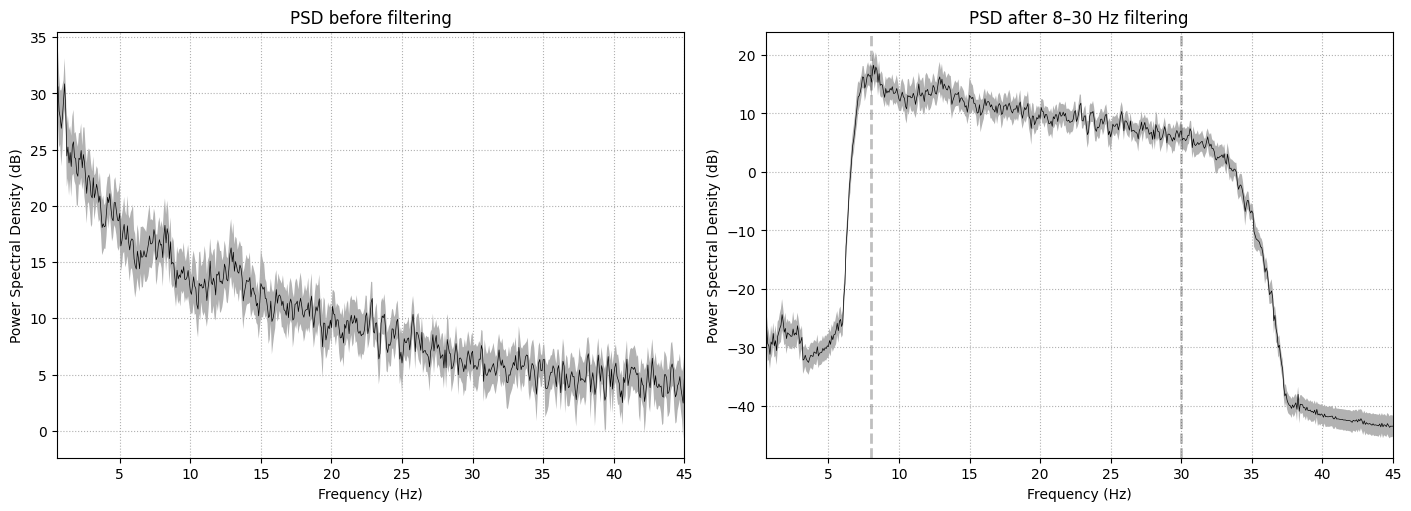

Saved figure to: ../figures/part2/psd_before_after_filtering.png


In [10]:
L_FREQ = 8.0
H_FREQ = 30.0
PSD_FMAX = 45.0

raw_s001_for_psd = raw_s001.copy()

print("Chosen band:", (L_FREQ, H_FREQ), "Hz")
print("Sampling frequency:", raw_s001_for_psd.info["sfreq"])
print("Number of EEG channels:", len(mne.pick_types(raw_s001_for_psd.info, eeg=True)))

# Keep only EEG channels for cleaner PSD visualization
raw_psd_input = raw_s001_for_psd.copy().pick("eeg")

# Filtered version for comparison
raw_psd_filtered = raw_psd_input.copy().filter(
    l_freq=L_FREQ,
    h_freq=H_FREQ,
    fir_design="firwin",
    verbose=False,
)

# Compute PSDs
psd_before = raw_psd_input.compute_psd(fmin=0.5, fmax=PSD_FMAX, verbose=False)
psd_after = raw_psd_filtered.compute_psd(fmin=0.5, fmax=PSD_FMAX, verbose=False)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

psd_before.plot(
    axes=axes[0],
    average=True,
    spatial_colors=False,
    show=False,
)
axes[0].set_title("PSD before filtering")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Power Spectral Density (dB)")

psd_after.plot(
    axes=axes[1],
    average=True,
    spatial_colors=False,
    show=False,
)
axes[1].set_title(f"PSD after {L_FREQ:.0f}–{H_FREQ:.0f} Hz filtering")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Power Spectral Density (dB)")

save_path = FIGURES_DIR / "psd_before_after_filtering.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {save_path}")

`Notes`:
- **Before filtering**: the spectrum has the expected broad EEG shape, with stronger low-frequency power and visible energy through the mu/beta region.
- **After 8–30 Hz filtering**: energy outside the target band is strongly attenuated, while the sensorimotor-relevant range is retained.

## Epoching around the cue

I will create cue-locked epochs for **left** and **right** motor imagery using:
- **Epoch window:** -1.0 s to 4.0 s
- **Baseline correction:** -1.0 s to 0.0 s

Why this window:
- It includes a clean pre-cue baseline.
- It captures the cue onset and the sustained imagery period after the cue.

For now, I am doing this on **one subject** to verify:
- event extraction,
- label mapping,
- epoch counts,
- and tensor shape before scaling to all subjects.

In [11]:
# parameters
TMIN_EPOCH = -1.0
TMAX_EPOCH = 4.0
BASELINE = (-1.0, 0.0)

# Consider one subject for verification
raw_s001_epoch_input = raw_s001.copy().pick("eeg")

# Filter
raw_s001_epoch_filtered = raw_s001_epoch_input.copy().filter(
    l_freq=L_FREQ,
    h_freq=H_FREQ,
    fir_design="firwin",
    verbose=False,
)

# Convert annotations to events
s001_events, s001_annot_event_id = mne.events_from_annotations(raw_s001_epoch_filtered, verbose=False)

print(f"Annotation event mapping: {s001_annot_event_id}\n")

# Keep only imagery events
if "T1" not in s001_annot_event_id or "T2" not in s001_annot_event_id:
    raise ValueError(f"Expected T1 and T2 in annotations, got: {s001_annot_event_id}")

event_id = {
    "left": s001_annot_event_id["T1"],
    "right": s001_annot_event_id["T2"],
}

# Create epochs
epochs_s001 = mne.Epochs(
    raw_s001_epoch_filtered,
    s001_events,
    event_id=event_id,
    tmin=TMIN_EPOCH,
    tmax=TMAX_EPOCH,
    baseline=BASELINE,
    preload=True,
    verbose=False,
)

print(f"S001 epoch info:\n{epochs_s001}")
print("Epoch data shape:", epochs_s001.get_data().shape)
print("Left epochs:", len(epochs_s001["left"]))
print("Right epochs:", len(epochs_s001["right"]))

# Keep for later steps
EPOCH_TMIN = TMIN_EPOCH
EPOCH_TMAX = TMAX_EPOCH
EPOCH_BASELINE = BASELINE

Annotation event mapping: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}

S001 epoch info:
<Epochs | 15 events (all good), -1 – 4 s (baseline -1 – 0 s), ~5.9 MiB, data loaded,
 'left': 8
 'right': 7>
Epoch data shape: (15, 64, 801)
Left epochs: 8
Right epochs: 7


## Time-resolved band-power inspection for window choice

Central channels used: ['C3..', 'Cz..', 'C4..']


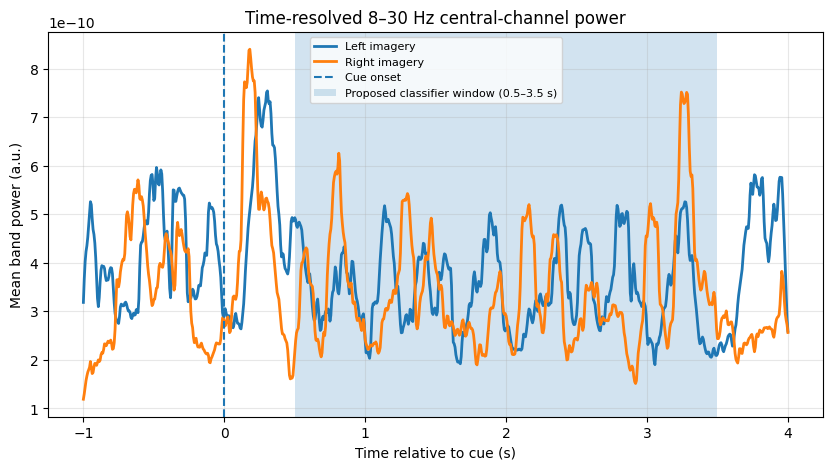

In [12]:
# Choose one epoch object BEFORE crop
epochs_window_check = epochs_s001.copy()

# find central channels robustly
def clean_name(name: str) -> str:
    return name.rstrip(".").strip().lower()

wanted_centrals = {"c3", "cz", "c4"}
central_picks = [
    ch for ch in epochs_window_check.ch_names
    if clean_name(ch) in wanted_centrals
]

print("Central channels used:", central_picks)

if len(central_picks) == 0:
    raise ValueError("Could not find C3/Cz/C4 in the epoch channels.")

# Pick central channels only
epochs_central = epochs_window_check.copy().pick(central_picks)

# Get left/right data
X_left = epochs_central["left"].get_data() # shape: (n_left, n_ch, n_times)
X_right = epochs_central["right"].get_data() # shape: (n_right, n_ch, n_times)

times = epochs_central.times

# Since epochs are already band-pass filtered (8–30 Hz),
# use squared amplitude as a simple time-resolved band-power proxy
power_left = (X_left ** 2).mean(axis=(0, 1))
power_right = (X_right ** 2).mean(axis=(0, 1))

# Optional light smoothing for readability (100 ms moving average)
sfreq = epochs_central.info["sfreq"]
smooth_ms = 100
win = max(1, int(round((smooth_ms / 1000) * sfreq)))
kernel = np.ones(win) / win

power_left_smooth = np.convolve(power_left, kernel, mode="same")
power_right_smooth = np.convolve(power_right, kernel, mode="same")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(times, power_left_smooth, label="Left imagery", linewidth=2)
ax.plot(times, power_right_smooth, label="Right imagery", linewidth=2)

# Cue line
ax.axvline(0, linestyle="--", linewidth=1.5, label="Cue onset")

# Proposed classifier window
ax.axvspan(0.5, 3.5, alpha=0.2, label="Proposed classifier window (0.5–3.5 s)")

ax.set_title("Time-resolved 8–30 Hz central-channel power")
ax.set_xlabel("Time relative to cue (s)")
ax.set_ylabel("Mean band power (a.u.)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.show()

`Notes`:
- The earliest post-cue region (roughly the first few hundred milliseconds) shows sharp transient changes, which likely reflect cue-related transition effects rather than the most stable sustained motor imagery activity. In contrast, the interval from about `0.5 s` onward shows continued band-power variation and visible differences between left and right imagery curves.
- Based on this inspection, I used `0.5–3.5 s` as the classifier window because it avoids the immediate cue-onset transition, captures a broader sustained imagery period, and provides a consistent fixed window across all subjects.

## Classifier time window inside the epoch

For CSP + classifier training, I will not use the entire `-1 to 4 s` epoch.

Instead, I will use a narrower **classifier window** from **0.5 s to 3.5 s**.

Why:
- the earliest post-cue samples may contain cue-related transition effects,
- motor imagery is better represented in the sustained post-cue period,
- CSP works on variance structure, so using a focused imagery window is usually cleaner than using the whole epoch.

In [13]:
# parameters
CLF_TMIN = 0.5
CLF_TMAX = 3.5

# Crop a copy only for modeling
epochs_s001_clf = epochs_s001.copy().crop(tmin=CLF_TMIN, tmax=CLF_TMAX)

X_s001 = epochs_s001_clf.get_data()   # (n_trials, n_channels, n_times)
y_s001 = epochs_s001_clf.events[:, 2] # currently event codes: left/right

print(f"Classifier window: {(CLF_TMIN, CLF_TMAX)} seconds")
print(f"Cropped epoch shape: {X_s001.shape}")
print(f"Unique labels: {sorted(set(y_s001.tolist()))}")

# For later steps
CLASSIFIER_TMIN = CLF_TMIN
CLASSIFIER_TMAX = CLF_TMAX

Classifier window: (0.5, 3.5) seconds
Cropped epoch shape: (15, 64, 481)
Unique labels: [2, 3]


`Notes`:

Why 481 time points makes sense:
- classifier window is 0.5 to 3.5 s, that is 3.0 seconds
- at 160 Hz, that gives about `3.0 × 160 = 480` samples
- MNE includes the endpoint here, so `481` is expected

And `Unique labels: [2, 3]` means the cropped epochs still correctly preserve:
- `2` = left
- `3` = right

## Prepare binary labels and first CSP-ready split

For CSP + classifier training, I will convert the event labels into clean binary targets:
- `0 = left`
- `1 = right`

This makes later classifier code easier to read and debug.

At this stage, I am creating only a **small stratified train/test split** on one subject to verify:
- feature tensor shape,
- binary labels,
- class balance,
- and CSP input readiness.

This is only a sanity-check step.
The final evaluation will use session-based validation across runs.

In [14]:
from sklearn.model_selection import train_test_split

# Read label mapping from the epochs object directly
print("Epoch event_id mapping:", epochs_s001_clf.event_id)

left_code = epochs_s001_clf.event_id["left"]
right_code = epochs_s001_clf.event_id["right"]

# Convert [2, 3] -> [0, 1]
# 0 = left, 1 = right
y_s001_binary = np.where(y_s001 == left_code, 0, 1)

print(f"Binary label values: {sorted(np.unique(y_s001_binary).tolist())}")
print(f"Total trials: {len(y_s001_binary)}")
print(f"Left trials (0): {int((y_s001_binary == 0).sum())}")
print(f"Right trials (1): {int((y_s001_binary == 1).sum())}")

# CSP-ready split for debugging
X_train, X_test, y_train, y_test = train_test_split(
    X_s001,
    y_s001_binary,
    test_size=0.33,
    random_state=42,
    stratify=y_s001_binary,
)

print(f"\nTrain shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Train class counts: {np.bincount(y_train)}")
print(f"Test class counts: {np.bincount(y_test)}")

Epoch event_id mapping: {'left': 2, 'right': 3}
Binary label values: [0, 1]
Total trials: 15
Left trials (0): 8
Right trials (1): 7

Train shape: (10, 64, 481)
Test shape: (5, 64, 481)
Train class counts: [5 5]
Test class counts: [3 2]


`Notes`:

The cropped motor imagery epochs were converted into clean binary targets for modeling:
- `0 = left`
- `1 = right`

This verification step confirms that:
- the event mapping is correct (`left = 2`, `right = 3` before remapping),
- the labels are now in a classifier-friendly binary format,
- the single-subject dataset is nearly balanced (`8` left vs `7` right trials),
- and the train/test split preserved class balance reasonably well.

The resulting tensors have the expected 3D shape for CSP input:
- train: `(10, 64, 481)`
- test: `(5, 64, 481)`

This means each sample still represents **one single epoch/trial**, with:
- `64` EEG channels
- `481` time points from the selected classifier window (`0.5–3.5 s`)

Overall, this confirms that the data is ready for CSP transformation.

## CSP transform on training data only

I will now fit **Common Spatial Pattern (CSP)** using only the training split.

This is important because CSP is a learned spatial transform.
To avoid data leakage:
- CSP must be fit on the training data only,
- then applied to the held-out test data.

For this sanity check, I will keep:
- **4 CSP components**

After CSP, each trial will no longer be represented as a full `(channels × time)` signal.
Instead, each trial becomes a **small feature vector** based on the variance structure of the most discriminative spatial components.

In [15]:
# Parameters
N_COMPONENTS = 4

# Create CSP object
csp_debug = CSP(
    n_components=N_COMPONENTS,
    reg=None,
    log=True,
    norm_trace=False,
)

# Fit on TRAIN ONLY, then transform train/test
X_train_csp = csp_debug.fit_transform(X_train, y_train)
X_test_csp = csp_debug.transform(X_test)

print(f"Original train shape: {X_train.shape}")
print(f"Original test shape: {X_test.shape}")
print(f"CSP train feature shape: {X_train_csp.shape}")
print(f"CSP test feature shape: {X_test_csp.shape}")

print("\nFirst 3 transformed train rows:")
print(np.round(X_train_csp[:3], 4))

# For next step
CSP_N_COMPONENTS = N_COMPONENTS
csp_s001_debug = csp_debug

Original train shape: (10, 64, 481)
Original test shape: (5, 64, 481)
CSP train feature shape: (10, 4)
CSP test feature shape: (5, 4)

First 3 transformed train rows:
[[-1.4158 -0.5121 -0.314  -1.1231]
 [-0.5065 -1.1632 -1.2395 -0.1986]
 [-0.8616 -1.6472 -1.3489 -0.7087]]


`Notes`:
- CSP was fit without leakage on the training split only
- each trial was reduced from a `64 × 481 signal` to a `4-feature vector`
- the data are now in the exact 2D shape that LDA/SVM expects:
    - `train: (10, 4)`
    - `test: (5, 4)`

## LDA baseline on CSP features

I will now train a simple **Linear Discriminant Analysis (LDA)** classifier on the CSP-transformed training features and evaluate it on the held-out test split.

This is only a **single-subject sanity-check baseline** to verify that:
- CSP features can be passed into a classifier,
- predictions can be generated correctly,
- and the full pipeline from `epochs → CSP → classifier` is functioning end-to-end.

In [16]:
# Create and fit LDA
lda_debug = LinearDiscriminantAnalysis(solver="svd")
lda_debug.fit(X_train_csp, y_train)

# Predict on test set
y_test_pred = lda_debug.predict(X_test_csp)

# Metrics
acc = accuracy_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print(f"LDA test accuracy: {round(acc, 4)}",)
print(f"True labels: {y_test.tolist()}")
print(f"Predicted labels: {y_test_pred.tolist()}")
print(f"\nConfusion matrix:\n{cm}")

print("\nClassification report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["left", "right"],
    digits=4
))

# Small readable table
debug_preds_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_test_pred,
    "true_label": ["left" if y == 0 else "right" for y in y_test],
    "pred_label": ["left" if y == 0 else "right" for y in y_test_pred],
})

display(debug_preds_df)

# For next step
lda_s001_debug = lda_debug
y_test_pred_lda = y_test_pred

LDA test accuracy: 1.0
True labels: [1, 0, 0, 1, 0]
Predicted labels: [1, 0, 0, 1, 0]

Confusion matrix:
[[3 0]
 [0 2]]

Classification report:
              precision    recall  f1-score   support

        left     1.0000    1.0000    1.0000         3
       right     1.0000    1.0000    1.0000         2

    accuracy                         1.0000         5
   macro avg     1.0000    1.0000    1.0000         5
weighted avg     1.0000    1.0000    1.0000         5



,y_true,y_pred,true_label,pred_label
0,1,1,right,right
1,0,0,left,left
2,0,0,left,left
3,1,1,right,right
4,0,0,left,left


`Sanity-check insights`:

The CSP + LDA sanity-check pipeline ran successfully from start to finish on one subject.

Results on the held-out debug split:
- **Accuracy:** 1.00
- **Confusion matrix:** perfect separation for this tiny test split
- **Both classes appeared in prediction output**, which confirms that the model did not collapse to a single-class guess.

This result is useful only as a **pipeline verification step**:
- epoching worked,
- CSP features were learned correctly from the training data,
- and LDA could classify the transformed trials.

However, this is **not** considered as final model performance because:
- the split is very small,
- it is based on only one subject,
- and it does not yet follow the final session-based cross-validation strategy required.

### Save confusion matrix plot for the first debug baseline

Save a confusion matrix figure for the single-subject CSP + LDA sanity check.

This figure is mainly useful for:
- debugging the pipeline,
- documenting the first successful end-to-end classification run,
- and later comparing against the final session-based evaluation figures.

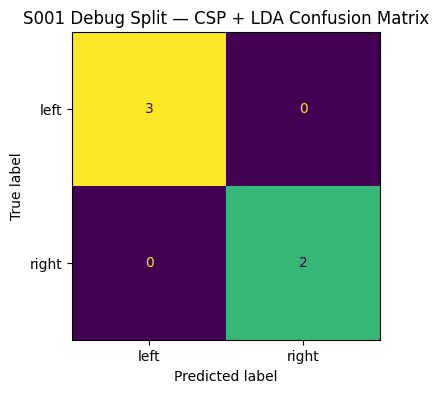

Saved confusion matrix to: ../figures/part2/s001_debug_confusion_matrix_lda.png


In [17]:
fig, ax = plt.subplots(figsize=(5, 4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["left", "right"]
)
disp.plot(ax=ax, colorbar=False)

ax.set_title("S001 Debug Split — CSP + LDA Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

cm_save_path = FIGURES_DIR / "s001_debug_confusion_matrix_lda.png"
fig.savefig(cm_save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved confusion matrix to: {cm_save_path}")

## SVM baseline on the same CSP features

To compare classifiers fairly, I will keep the same:
- subject
- epochs
- classifier window
- train/test split
- CSP features

and replace only the classifier.

I will use a **linear SVM** as the second baseline model.
This provides the first direct comparison:
- **CSP + LDA**
- **CSP + SVM**

In [18]:
# Create and fit SVM
svm_debug = SVC(kernel="linear", C=1.0)
svm_debug.fit(X_train_csp, y_train)

# Predict on test set
y_test_pred_svm = svm_debug.predict(X_test_csp)

# Metrics
acc_svm = accuracy_score(y_test, y_test_pred_svm)
cm_svm = confusion_matrix(y_test, y_test_pred_svm)

print(f"SVM test accuracy: {round(acc_svm, 4)}")
print(f"True labels: {y_test.tolist()}")
print(f"Predicted labels: {y_test_pred_svm.tolist()}")
print(f"\nConfusion matrix:\n{cm_svm}")

print("\nClassification report:")
print(classification_report(
    y_test,
    y_test_pred_svm,
    target_names=["left", "right"],
    digits=4
))

# Small readable table
svm_preds_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_test_pred_svm,
    "true_label": ["left" if y == 0 else "right" for y in y_test],
    "pred_label": ["left" if y == 0 else "right" for y in y_test_pred_svm],
})

display(svm_preds_df)

# For next step
svm_s001_debug = svm_debug

SVM test accuracy: 0.6
True labels: [1, 0, 0, 1, 0]
Predicted labels: [1, 1, 1, 1, 0]

Confusion matrix:
[[1 2]
 [0 2]]

Classification report:
              precision    recall  f1-score   support

        left     1.0000    0.3333    0.5000         3
       right     0.5000    1.0000    0.6667         2

    accuracy                         0.6000         5
   macro avg     0.7500    0.6667    0.5833         5
weighted avg     0.8000    0.6000    0.5667         5



,y_true,y_pred,true_label,pred_label
0,1,1,right,right
1,0,1,left,right
2,0,1,left,right
3,1,1,right,right
4,0,0,left,left


`Sanity-check insights`:

On this small single-subject debug split, **CSP + LDA** outperformed **CSP + linear SVM**.

Observed behavior:
- **LDA accuracy:** 1.00
- **SVM accuracy:** 0.60

The SVM model showed a tendency to predict the **right** class more often, which reduced recall for the **left** class:
- left recall = 0.3333
- right recall = 1.0000

This comparison is still only a **debugging result**, not a final conclusion, because:
- the test set is extremely small,
- only one subject is involved,
- and the final evaluation will be session-based across the full dataset.

This step is useful because it confirms that both required classifier branches are working:
- **CSP + LDA**
- **CSP + SVM**

### Save SVM confusion matrix and summarize the first classifier comparison

I will save the confusion matrix for the SVM debug run and create a small comparison table between:
- CSP + LDA
- CSP + SVM

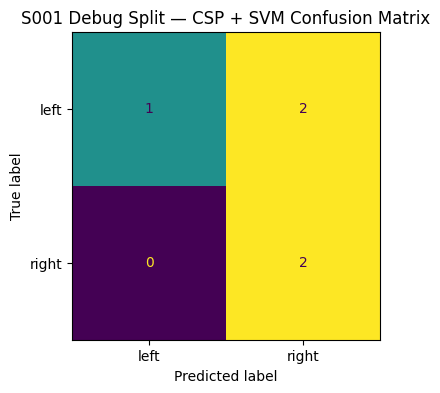

Saved SVM confusion matrix to: ../figures/part2/s001_debug_confusion_matrix_svm.png


,model,accuracy,n_test_trials,notes
0,CSP + LDA,1.0,5,Perfect on tiny debug split
1,CSP + SVM (linear),0.6,5,Predicted right more often on tiny debug split


In [19]:
# Save SVM confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["left", "right"]
)
disp.plot(ax=ax, colorbar=False)

ax.set_title("S001 Debug Split — CSP + SVM Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

svm_cm_save_path = FIGURES_DIR / "s001_debug_confusion_matrix_svm.png"
fig.savefig(svm_cm_save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved SVM confusion matrix to: {svm_cm_save_path}")

# Small comparison table
debug_model_compare_df = pd.DataFrame({
    "model": ["CSP + LDA", "CSP + SVM (linear)"],
    "accuracy": [acc, acc_svm],
    "n_test_trials": [len(y_test), len(y_test)],
    "notes": [
        "Perfect on tiny debug split",
        "Predicted right more often on tiny debug split"
    ]
})

display(debug_model_compare_df)

## Prepare one subject’s 3-run dataset for Leave-One-Session-Out

For the real evaluation design, I need to preserve the natural session structure of the dataset:
- `R04`
- `R08`
- `R12`

In this step, I will:
1. load all 3 imagery runs for one subject,
2. epoch them using the same preprocessing choices,
3. attach the run/session ID to every epoch,
4. concatenate the epochs into one subject-level dataset.

This keeps **each trial as one record**, while also preserving **which session/run it came from**, which is required for Leave-One-Session-Out validation.

In [20]:
# Parameters
DEBUG_SUBJECT = "S001"
DEBUG_RUNS = [4, 8, 12]

subject_epochs_by_run = []

for run in DEBUG_RUNS:
    run_label = f"R{run:02d}"

    # Load the data
    subject_edf_path = DATA_DIR / DEBUG_SUBJECT / f"{DEBUG_SUBJECT}{run_label}.edf"
    if not subject_edf_path:
        print(f"Run {run_label} file does not exists")
    raw_subject_run = mne.io.read_raw_edf(subject_edf_path, preload=True, verbose=False)
    print(f"Loaded basename: {subject_edf_path.name}")

    raw_subject_run_eeg = raw_subject_run.copy().pick("eeg")

    # Broad filter
    raw_subject_run_eeg = raw_subject_run_eeg.filter(
        l_freq=L_FREQ,
        h_freq=H_FREQ,
        fir_design="firwin",
        verbose=False,
    )

    # Events from annotations
    subject_events_run, subject_annot_event_id_run = mne.events_from_annotations(raw_subject_run_eeg, verbose=False)

    if "T1" not in subject_annot_event_id_run or "T2" not in subject_annot_event_id_run:
        raise ValueError(f"{run_label}: expected T1/T2, got {subject_annot_event_id_run}")

    subject_event_id_run = {
        "left": subject_annot_event_id_run["T1"],
        "right": subject_annot_event_id_run["T2"],
    }

    # Epoch this run
    subject_epochs_run = mne.Epochs(
        raw_subject_run_eeg,
        subject_events_run,
        event_id=subject_event_id_run,
        tmin=EPOCH_TMIN,
        tmax=EPOCH_TMAX,
        baseline=EPOCH_BASELINE,
        preload=True,
        verbose=False,
    )

    # Attach metadata so every epoch remembers its run/session
    label_codes = subject_epochs_run.events[:, 2]
    label_names = [
        "left" if code == subject_event_id_run["left"] else "right"
        for code in label_codes
    ]

    subject_metadata_run = pd.DataFrame({
        "subject_id": [DEBUG_SUBJECT] * len(subject_epochs_run),
        "run": [run] * len(subject_epochs_run),
        "run_label": [run_label] * len(subject_epochs_run),
        "label_name": label_names,
    })

    subject_epochs_run.metadata = subject_metadata_run
    subject_epochs_by_run.append(subject_epochs_run)

    print(
        f"{run_label}: total={len(subject_epochs_run)}, "
        f"left={(subject_metadata_run['label_name'] == 'left').sum()}, "
        f"right={(subject_metadata_run['label_name'] == 'right').sum()}"
    )

# Concatenate the 3 runs into one subject-level epoch object
subject_epochs_loso = mne.concatenate_epochs(subject_epochs_by_run)

print("\nCombined subject epochs:")
print(subject_epochs_loso)
print("Combined shape:", subject_epochs_loso.get_data().shape)

print("\nRun-by-label counts:")
display(pd.crosstab(
    subject_epochs_loso.metadata["run_label"],
    subject_epochs_loso.metadata["label_name"],
    margins=True
))

# For next step
epochs_debug_loso = subject_epochs_loso

Loaded basename: S001R04.edf
R04: total=15, left=8, right=7
Loaded basename: S001R08.edf
R08: total=15, left=8, right=7
Loaded basename: S001R12.edf
R12: total=15, left=7, right=8

Combined subject epochs:
<EpochsArray | 45 events (all good), -1 – 4 s (baseline -1 – 0 s), ~17.7 MiB, data loaded, with metadata,
 'left': 23
 'right': 22>
Combined shape: (45, 64, 801)

Run-by-label counts:


label_name,left,right,All
run_label,,,
R04,8,7,15
R08,8,7,15
R12,7,8,15
All,23,22,45


`Notes`:

For subject `S001`, all three motor imagery runs were loaded and epoched consistently:
- `R04`: 15 trials
- `R08`: 15 trials
- `R12`: 15 trials

After concatenation:
- total trials = `45`
- shape = `(45, 64, 801)`
- class balance remained nearly even (`23` left, `22` right)

Most importantly, each epoch now retains its **run/session identity** through metadata.
This means the dataset is correctly structured for **Leave-One-Session-Out** validation, where one run is held out for testing and the other two runs are used for training.

## One-subject Leave-One-Session-Out with CSP + LDA

I will now evaluate the session-based baseline for one subject.

For each fold:
- train on 2 runs
- test on the held-out run

In [21]:
# Parameters
N_COMPONENTS = 4

# Use the concatenated one-subject epochs from previous step
epochs_loso_clf = epochs_debug_loso.copy().crop(
    tmin=CLASSIFIER_TMIN,
    tmax=CLASSIFIER_TMAX,
)

X_all = epochs_loso_clf.get_data()
meta = epochs_loso_clf.metadata.copy()

# Binary labels: 0 = left, 1 = right
y_all = np.where(meta["label_name"].values == "left", 0, 1)
runs_all = meta["run_label"].values

fold_rows = []
all_y_true = []
all_y_pred = []

for held_out_run in sorted(meta["run_label"].unique()):
    train_mask = runs_all != held_out_run
    test_mask = runs_all == held_out_run

    X_train = X_all[train_mask]
    X_test = X_all[test_mask]
    y_train = y_all[train_mask]
    y_test = y_all[test_mask]

    # CSP fit only on training data
    csp = CSP(
        n_components=N_COMPONENTS,
        reg=None,
        log=True,
        norm_trace=False,
    )
    X_train_csp = csp.fit_transform(X_train, y_train)
    X_test_csp = csp.transform(X_test)

    # LDA
    lda = LinearDiscriminantAnalysis(solver="svd")
    lda.fit(X_train_csp, y_train)
    y_pred = lda.predict(X_test_csp)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    fold_rows.append({
        "held_out_run": held_out_run,
        "n_train": len(y_train),
        "n_test": len(y_test),
        "train_left": int((y_train == 0).sum()),
        "train_right": int((y_train == 1).sum()),
        "test_left": int((y_test == 0).sum()),
        "test_right": int((y_test == 1).sum()),
        "accuracy": acc,
        "tn_left_correct": int(cm[0, 0]),
        "fp_left_as_right": int(cm[0, 1]),
        "fn_right_as_left": int(cm[1, 0]),
        "tp_right_correct": int(cm[1, 1]),
    })

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

loso_folds_df = pd.DataFrame(fold_rows)

print("One-subject LOSO fold results:")
display(loso_folds_df)

print("Mean LOSO accuracy:", round(loso_folds_df["accuracy"].mean(), 4))

# Keep for next step
loso_s001_lda_df = loso_folds_df
loso_s001_y_true = np.array(all_y_true)
loso_s001_y_pred = np.array(all_y_pred)

One-subject LOSO fold results:


,held_out_run,n_train,n_test,train_left,train_right,test_left,test_right,accuracy,tn_left_correct,fp_left_as_right,fn_right_as_left,tp_right_correct
0,R04,30,15,15,15,8,7,0.466667,0,8,0,7
1,R08,30,15,15,15,8,7,0.733333,6,2,2,5
2,R12,30,15,16,14,7,8,0.666667,6,1,4,4


Mean LOSO accuracy: 0.6222


`Notes`:
- session-based pipeline is working
- performance is not uniformly stable across runs
- `R04` is the hardest held-out session here because the model predicted everything as right
- `R08` and `R12` are more reasonable

### Save aggregated LOSO confusion matrix for one subject

Aggregated LOSO confusion matrix:
[[12 11]
 [ 6 16]]


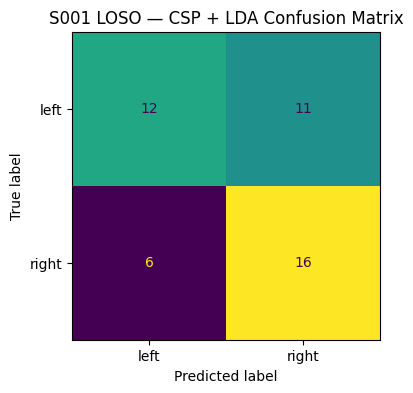

Saved LOSO confusion matrix to: ../figures/part2/s001_loso_confusion_matrix_lda.png

Classification report:
              precision    recall  f1-score   support

        left     0.6667    0.5217    0.5854        23
       right     0.5926    0.7273    0.6531        22

    accuracy                         0.6222        45
   macro avg     0.6296    0.6245    0.6192        45
weighted avg     0.6305    0.6222    0.6185        45



In [22]:
# Aggregate confusion matrix across all LOSO test folds
cm_loso_s001 = confusion_matrix(
    loso_s001_y_true,
    loso_s001_y_pred,
    labels=[0, 1]
)

print("Aggregated LOSO confusion matrix:")
print(cm_loso_s001)

fig, ax = plt.subplots(figsize=(5, 4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_loso_s001,
    display_labels=["left", "right"]
)
disp.plot(ax=ax, colorbar=False)

ax.set_title("S001 LOSO — CSP + LDA Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

loso_cm_save_path = FIGURES_DIR / "s001_loso_confusion_matrix_lda.png"
fig.savefig(loso_cm_save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved LOSO confusion matrix to: {loso_cm_save_path}")

print("\nClassification report:")
print(classification_report(
    loso_s001_y_true,
    loso_s001_y_pred,
    target_names=["left", "right"],
    digits=4
))

`Notes`:
- The model identified the **right** class better than the **left** class.
- **Right recall** is stronger (`0.7273`), meaning right trials were detected more consistently.
- **Left recall** is lower (`0.5217`), showing that many left trials were misclassified as right.

## One-subject Leave-One-Session-Out with CSP + SVM

I will now repeat the same one-subject LOSO evaluation using a **linear SVM** instead of LDA.

In [23]:
svm_fold_rows = []
svm_all_y_true = []
svm_all_y_pred = []

for held_out_run in sorted(meta["run_label"].unique()):
    train_mask = runs_all != held_out_run
    test_mask = runs_all == held_out_run

    X_train = X_all[train_mask]
    X_test = X_all[test_mask]
    y_train = y_all[train_mask]
    y_test = y_all[test_mask]

    # CSP fit only on training data
    csp = CSP(
        n_components=N_COMPONENTS,
        reg=None,
        log=True,
        norm_trace=False,
    )
    X_train_csp = csp.fit_transform(X_train, y_train)
    X_test_csp = csp.transform(X_test)

    # Linear SVM
    svm = SVC(kernel="linear", C=1.0)
    svm.fit(X_train_csp, y_train)
    y_pred = svm.predict(X_test_csp)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    svm_fold_rows.append({
        "held_out_run": held_out_run,
        "n_train": len(y_train),
        "n_test": len(y_test),
        "train_left": int((y_train == 0).sum()),
        "train_right": int((y_train == 1).sum()),
        "test_left": int((y_test == 0).sum()),
        "test_right": int((y_test == 1).sum()),
        "accuracy": acc,
        "tn_left_correct": int(cm[0, 0]),
        "fp_left_as_right": int(cm[0, 1]),
        "fn_right_as_left": int(cm[1, 0]),
        "tp_right_correct": int(cm[1, 1]),
    })

    svm_all_y_true.extend(y_test.tolist())
    svm_all_y_pred.extend(y_pred.tolist())

loso_s001_svm_df = pd.DataFrame(svm_fold_rows)

print("One-subject LOSO fold results — SVM:")
display(loso_s001_svm_df)

print("Mean LOSO accuracy (SVM):", round(loso_s001_svm_df["accuracy"].mean(), 4))

loso_s001_svm_y_true = np.array(svm_all_y_true)
loso_s001_svm_y_pred = np.array(svm_all_y_pred)

One-subject LOSO fold results — SVM:


,held_out_run,n_train,n_test,train_left,train_right,test_left,test_right,accuracy,tn_left_correct,fp_left_as_right,fn_right_as_left,tp_right_correct
0,R04,30,15,15,15,8,7,0.466667,0,8,0,7
1,R08,30,15,15,15,8,7,0.666667,6,2,3,4
2,R12,30,15,16,14,7,8,0.666667,6,1,4,4


Mean LOSO accuracy (SVM): 0.6


Aggregated LOSO confusion matrix — SVM:
[[12 11]
 [ 7 15]]


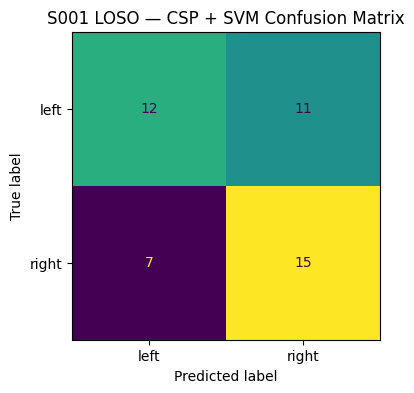

Saved LOSO confusion matrix to: ../figures/part2/s001_loso_confusion_matrix_svm.png

Classification report — SVM:
              precision    recall  f1-score   support

        left     0.6316    0.5217    0.5714        23
       right     0.5769    0.6818    0.6250        22

    accuracy                         0.6000        45
   macro avg     0.6043    0.6018    0.5982        45
weighted avg     0.6049    0.6000    0.5976        45



In [24]:
# Aggregated confusion matrix across all LOSO test folds
cm_loso_s001_svm = confusion_matrix(
    loso_s001_svm_y_true,
    loso_s001_svm_y_pred,
    labels=[0, 1]
)

print("Aggregated LOSO confusion matrix — SVM:")
print(cm_loso_s001_svm)

fig, ax = plt.subplots(figsize=(5, 4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_loso_s001_svm,
    display_labels=["left", "right"]
)
disp.plot(ax=ax, colorbar=False)

ax.set_title("S001 LOSO — CSP + SVM Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

svm_loso_cm_save_path = FIGURES_DIR / "s001_loso_confusion_matrix_svm.png"
fig.savefig(svm_loso_cm_save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved LOSO confusion matrix to: {svm_loso_cm_save_path}")

print("\nClassification report — SVM:")
print(classification_report(
    loso_s001_svm_y_true,
    loso_s001_svm_y_pred,
    target_names=["left", "right"],
    digits=4
))

## `S001` LOSO — LDA vs SVM

- **CSP + LDA:** mean LOSO accuracy = **0.6222**
- **CSP + SVM:** mean LOSO accuracy = **0.6000**

`Key takeaway`:
- LDA was slightly better than linear SVM for this subject.
- Both models classified **right imagery** more reliably than **left imagery**.
- Performance varied across runs, especially on **R04**, showing that session-level variability is an important challenge.
- For now, **CSP + LDA** is the stronger baseline to scale to all subjects first.

## Modeling design choice

I will be using a **subject-wise** CSP modeling strategy instead of pooling all subjects into one global model.

This choice is supported by [Ramoser et al. (2000)](https://ieeexplore.ieee.org/document/895946), where:
- each subject’s dataset was split into its own training and testing sets,
- the best classification time segment differed across subjects,
- and the CSP spatial patterns also varied by subject.

This suggests that motor imagery timing and spatial structure are partly individualized, so training separate subject-level models is more appropriate than forcing one pooled CSP model across all participants.

For this assignment, I keep that subject-wise modeling idea, but use **Leave-One-Session-Out** across runs (`R04`, `R08`, `R12`) to better test within-subject generalization across sessions.

## Reusable one-subject LOSO function

I will now package the subject-wise LOSO pipeline into a reusable function to keep the evaluation logic identical for every subject.

This function will:
- take one subject’s concatenated multi-run epochs,
- crop to the classifier window,
- build binary labels,
- run Leave-One-Session-Out across the run labels,
- fit CSP only on the training folds,
- train either LDA or SVM,
- and return fold-wise results plus all held-out predictions.

In [25]:
def make_classifier(classifier_name: str):
    """
    Simple classifier factory for the assignment baselines.
    """
    classifier_name = classifier_name.lower()

    if classifier_name == "lda":
        return LinearDiscriminantAnalysis(solver="svd")

    if classifier_name == "svm":
        return SVC(kernel="linear", C=1.0)

    raise ValueError(f"Unsupported classifier_name: {classifier_name}")

def run_subject_loso_csp_clf(
    epochs_subject_loso,
    classifier_name: str = "lda",
    clf_tmin: float = 0.5,
    clf_tmax: float = 3.5,
    n_components: int = 4,
):
    """
    Run subject-wise Leave-One-Session-Out CSP + classifier.

    Args:
    epochs_subject_loso : mne.Epochs
        Concatenated epochs for one subject across multiple runs.
        Must contain metadata columns:
        - 'label_name' : 'left' / 'right'
        - 'run_label'  : e.g. 'R04', 'R08', 'R12'
    classifier_name : str
        'lda' or 'svm'
    clf_tmin, clf_tmax : float
        Time window inside the epoch used for modeling.
    n_components : int
        Number of CSP components.

    Returns:
    fold_df : pd.DataFrame
        Fold-wise LOSO metrics.
    y_true_all : np.ndarray
        Concatenated ground-truth labels from all held-out folds.
    y_pred_all : np.ndarray
        Concatenated predicted labels from all held-out folds.
    """

    # Defensive checks
    if epochs_subject_loso.metadata is None:
        raise ValueError("epochs_subject_loso must contain metadata.")

    required_cols = {"label_name", "run_label"}
    missing_cols = required_cols - set(epochs_subject_loso.metadata.columns)
    if missing_cols:
        raise ValueError(f"Missing metadata columns: {missing_cols}")

    # Crop to the classifier window
    epochs_clf = epochs_subject_loso.copy().crop(tmin=clf_tmin, tmax=clf_tmax)

    X_all = epochs_clf.get_data()
    meta = epochs_clf.metadata.copy()

    # Binary labels: 0 = left, 1 = right
    y_all = np.where(meta["label_name"].values == "left", 0, 1)
    runs_all = meta["run_label"].values

    fold_rows = []
    y_true_all = []
    y_pred_all = []

    unique_runs = sorted(pd.unique(runs_all))

    for held_out_run in unique_runs:
        train_mask = runs_all != held_out_run
        test_mask = runs_all == held_out_run

        X_train = X_all[train_mask]
        X_test = X_all[test_mask]
        y_train = y_all[train_mask]
        y_test = y_all[test_mask]

        # CSP fit ONLY on training data
        csp = CSP(
            n_components=n_components,
            reg=None,
            log=True,
            norm_trace=False,
        )
        X_train_csp = csp.fit_transform(X_train, y_train)
        X_test_csp = csp.transform(X_test)

        clf = make_classifier(classifier_name)
        clf.fit(X_train_csp, y_train)
        y_pred = clf.predict(X_test_csp)

        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

        fold_rows.append({
            "held_out_run": held_out_run,
            "classifier": classifier_name.lower(),
            "n_train": len(y_train),
            "n_test": len(y_test),
            "train_left": int((y_train == 0).sum()),
            "train_right": int((y_train == 1).sum()),
            "test_left": int((y_test == 0).sum()),
            "test_right": int((y_test == 1).sum()),
            "accuracy": acc,
            "tn_left_correct": int(cm[0, 0]),
            "fp_left_as_right": int(cm[0, 1]),
            "fn_right_as_left": int(cm[1, 0]),
            "tp_right_correct": int(cm[1, 1]),
        })

        y_true_all.extend(y_test.tolist())
        y_pred_all.extend(y_pred.tolist())

    fold_df = pd.DataFrame(fold_rows)

    return fold_df, np.array(y_true_all), np.array(y_pred_all)

In [26]:
# Verification
s001_loso_lda_df_v2, s001_loso_lda_y_true_v2, s001_loso_lda_y_pred_v2 = run_subject_loso_csp_clf(
    epochs_subject_loso=epochs_debug_loso,
    classifier_name="lda",
    clf_tmin=CLASSIFIER_TMIN,
    clf_tmax=CLASSIFIER_TMAX,
    n_components=4,
)

display(s001_loso_lda_df_v2)
print("Mean LOSO accuracy (function, LDA):", round(s001_loso_lda_df_v2["accuracy"].mean(), 4))

,held_out_run,classifier,n_train,n_test,train_left,train_right,test_left,test_right,accuracy,tn_left_correct,fp_left_as_right,fn_right_as_left,tp_right_correct
0,R04,lda,30,15,15,15,8,7,0.466667,0,8,0,7
1,R08,lda,30,15,15,15,8,7,0.733333,6,2,2,5
2,R12,lda,30,15,16,14,7,8,0.666667,6,1,4,4


Mean LOSO accuracy (function, LDA): 0.6222


## Reusable function to build one subject's LOSO-ready epochs

Before looping over all subjects, I will package the multi-run loading and epoching logic into one reusable function to keep the data preparation identical for every subject before running the CSP + classifier pipeline.

This function will:
- load runs `R04`, `R08`, and `R12` for one subject,
- apply the same band-pass filter,
- convert annotations to left/right events,
- epoch each run consistently,
- attach run metadata,
- and concatenate all runs into one LOSO-ready Epochs object.

In [27]:
def clean_channel_names(raw):
    """Remove trailing dots from channel names like C3.. -> C3."""
    rename_map = {ch: ch.rstrip(".") for ch in raw.ch_names}
    mne.rename_channels(raw.info, rename_map)
    return raw

def build_subject_loso_epochs(
    subject_id: str,
    data_dir: Path,
    runs=(4, 8, 12),
    l_freq: float = 8.0,
    h_freq: float = 30.0,
    tmin_epoch: float = -1.0,
    tmax_epoch: float = 4.0,
    baseline=(-1.0, 0.0),
):
    """
    Load one subject's imagery runs, epoch them consistently,
    attach run metadata, and concatenate into one LOSO-ready Epochs object.

    Expected file pattern:
        data_dir / subject_id / f"{subject_id}RXX.edf"
    """

    epochs_by_run = []

    for run in runs:
        run_label = f"R{run:02d}"
        edf_path = data_dir / subject_id / f"{subject_id}{run_label}.edf"

        if not edf_path.exists():
            raise FileNotFoundError(f"Missing EDF file: {edf_path}")

        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        raw = clean_channel_names(raw)
        raw = raw.copy().pick("eeg")
        
        montage = mne.channels.make_standard_montage("standard_1005")
        raw.set_montage(
            montage,
            match_case=False,
            on_missing="ignore",
        )

        raw = raw.filter(
            l_freq=l_freq,
            h_freq=h_freq,
            fir_design="firwin",
            verbose=False,
        )

        events, annot_event_id = mne.events_from_annotations(raw, verbose=False)

        if "T1" not in annot_event_id or "T2" not in annot_event_id:
            raise ValueError(
                f"{subject_id} {run_label}: expected T1/T2, got {annot_event_id}"
            )

        event_id = {
            "left": annot_event_id["T1"],
            "right": annot_event_id["T2"],
        }

        epochs_run = mne.Epochs(
            raw,
            events,
            event_id=event_id,
            tmin=tmin_epoch,
            tmax=tmax_epoch,
            baseline=baseline,
            preload=True,
            verbose=False,
        )

        label_codes = epochs_run.events[:, 2]
        label_names = [
            "left" if code == event_id["left"] else "right"
            for code in label_codes
        ]

        metadata_run = pd.DataFrame({
            "subject_id": [subject_id] * len(epochs_run),
            "run": [run] * len(epochs_run),
            "run_label": [run_label] * len(epochs_run),
            "label_name": label_names,
        })

        epochs_run.metadata = metadata_run
        epochs_by_run.append(epochs_run)

    epochs_subject_loso = mne.concatenate_epochs(epochs_by_run)

    return epochs_subject_loso

In [ ]:
# Verification
epochs_s001_loso_v2 = build_subject_loso_epochs(
    subject_id="S001",
    data_dir=DATA_DIR,
    runs=(4, 8, 12),
    l_freq=L_FREQ,
    h_freq=H_FREQ,
    tmin_epoch=EPOCH_TMIN,
    tmax_epoch=EPOCH_TMAX,
    baseline=EPOCH_BASELINE,
)

print(epochs_s001_loso_v2)
print("Shape:", epochs_s001_loso_v2.get_data().shape)

display(pd.crosstab(
    epochs_s001_loso_v2.metadata["run_label"],
    epochs_s001_loso_v2.metadata["label_name"],
    margins=True
))

<EpochsArray | 45 events (all good), -1 – 4 s (baseline -1 – 0 s), ~17.7 MiB, data loaded, with metadata,
 'left': 23
 'right': 22>
Shape: (45, 64, 801)


label_name,left,right,All
run_label,,,
R04,8,7,15
R08,8,7,15
R12,7,8,15
All,23,22,45


## All-subject baseline with subject-wise LOSO and CSP + LDA

I will now run the full baseline across the clean subject pool.

Design:
- subject-wise modeling
- runs `R04`, `R08`, `R12`
- Leave-One-Session-Out within each subject
- CSP fit only on training folds
- classifier = LDA

In [29]:
all_subject_summary_rows = []
all_subject_fold_rows = []
failed_subject_rows = []

for subject_id in CLEAN_SUBJECTS:
    try:
        # Build this subject's LOSO-ready epochs
        epochs_subject = build_subject_loso_epochs(
            subject_id=subject_id,
            data_dir=DATA_DIR,
            runs=(4, 8, 12),
            l_freq=L_FREQ,
            h_freq=H_FREQ,
            tmin_epoch=EPOCH_TMIN,
            tmax_epoch=EPOCH_TMAX,
            baseline=EPOCH_BASELINE,
        )

        # Run subject-wise LOSO CSP + LDA
        fold_df, y_true_all, y_pred_all = run_subject_loso_csp_clf(
            epochs_subject_loso=epochs_subject,
            classifier_name="lda",
            clf_tmin=CLASSIFIER_TMIN,
            clf_tmax=CLASSIFIER_TMAX,
            n_components=4,
        )

        # Add subject id to fold rows
        fold_df = fold_df.copy()
        fold_df["subject_id"] = subject_id
        all_subject_fold_rows.append(fold_df)

        # Subject summary
        subject_summary = {
            "subject_id": subject_id,
            "classifier": "lda",
            "n_total_trials": len(y_true_all),
            "n_left_trials": int((y_true_all == 0).sum()),
            "n_right_trials": int((y_true_all == 1).sum()),
            "mean_loso_accuracy": fold_df["accuracy"].mean(),
            "std_loso_accuracy": fold_df["accuracy"].std(ddof=0),
            "min_fold_accuracy": fold_df["accuracy"].min(),
            "max_fold_accuracy": fold_df["accuracy"].max(),
        }
        all_subject_summary_rows.append(subject_summary)

        print(f"{subject_id}: mean LOSO accuracy = {subject_summary['mean_loso_accuracy']:.4f}")

    except Exception as e:
        failed_subject_rows.append({
            "subject_id": subject_id,
            "error": str(e),
        })
        print(f"{subject_id}: FAILED -> {e}")

# Combine results
all_subject_lda_summary_df = pd.DataFrame(all_subject_summary_rows).sort_values(
    by="mean_loso_accuracy", ascending=False
).reset_index(drop=True)

all_subject_lda_folds_df = pd.concat(all_subject_fold_rows, ignore_index=True) if all_subject_fold_rows else pd.DataFrame()
failed_subjects_df = pd.DataFrame(failed_subject_rows)

print("\nFinished all-subject LDA baseline.")
print("Successful subjects:", len(all_subject_lda_summary_df))
print("Failed subjects:", len(failed_subjects_df))

if len(all_subject_lda_summary_df) > 0:
    print("\nOverall mean LOSO accuracy across subjects:",
          round(all_subject_lda_summary_df["mean_loso_accuracy"].mean(), 4))
    print("Median subject accuracy:",
          round(all_subject_lda_summary_df["mean_loso_accuracy"].median(), 4))

display(all_subject_lda_summary_df.head(10))

if len(failed_subjects_df) > 0:
    print("\nFailed subjects:")
    display(failed_subjects_df)

# Keep for next steps
subject_summary_lda_df = all_subject_lda_summary_df
subject_folds_lda_df = all_subject_lda_folds_df
subject_failures_lda_df = failed_subjects_df

S001: mean LOSO accuracy = 0.6222
S002: mean LOSO accuracy = 0.9111
S003: mean LOSO accuracy = 0.6000
S004: mean LOSO accuracy = 0.5333
S005: mean LOSO accuracy = 0.5111
S006: mean LOSO accuracy = 0.5556
S007: mean LOSO accuracy = 0.9778
S008: mean LOSO accuracy = 0.5556
S009: mean LOSO accuracy = 0.5333
S010: mean LOSO accuracy = 0.5778
S011: mean LOSO accuracy = 0.6222
S012: mean LOSO accuracy = 0.5556
S013: mean LOSO accuracy = 0.5556
S014: mean LOSO accuracy = 0.5333
S015: mean LOSO accuracy = 0.6444
S016: mean LOSO accuracy = 0.4889
S017: mean LOSO accuracy = 0.4889
S018: mean LOSO accuracy = 0.4444
S019: mean LOSO accuracy = 0.4667
S020: mean LOSO accuracy = 0.5556
S021: mean LOSO accuracy = 0.4667
S022: mean LOSO accuracy = 0.6889
S023: mean LOSO accuracy = 0.5556
S024: mean LOSO accuracy = 0.5333
S025: mean LOSO accuracy = 0.6667
S026: mean LOSO accuracy = 0.7333
S027: mean LOSO accuracy = 0.6667
S028: mean LOSO accuracy = 0.4444
S029: mean LOSO accuracy = 1.0000
S030: mean LOS

,subject_id,classifier,n_total_trials,n_left_trials,n_right_trials,mean_loso_accuracy,std_loso_accuracy,min_fold_accuracy,max_fold_accuracy
0,S029,lda,45,23,22,1.000000,0.000000,1.000000,1.000000
1,S007,lda,45,23,22,0.977778,0.031427,0.933333,1.000000
2,S002,lda,45,23,22,0.911111,0.083148,0.800000,1.000000
3,S085,lda,45,23,22,0.911111,0.083148,0.800000,1.000000
4,S072,lda,43,22,21,0.906349,0.089538,0.785714,1.000000
5,S034,lda,43,21,22,0.904762,0.067344,0.857143,1.000000
6,S053,lda,45,22,23,0.888889,0.062854,0.800000,0.933333
7,S062,lda,45,23,22,0.888889,0.157135,0.666667,1.000000
8,S042,lda,45,22,23,0.866667,0.108866,0.733333,1.000000
9,S031,lda,45,22,23,0.866667,0.054433,0.800000,0.933333


`Notes`:
- The baseline is above chance, but not uniformly strong.
- Performance varies a lot across subjects, from very weak cases to near-perfect cases.
- This suggests that motor imagery patterns are not equally stable across all subjects/sessions.
- That session-to-session variability is a major challenge.

In [30]:
# Save the all-subject LDA summary tables
BASELINE_RESULTS_DIR = RESULTS_DIR / "baseline"
BASELINE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

lda_summary_path = BASELINE_RESULTS_DIR / "all_subjects_loso_lda_summary.csv"
lda_folds_path = BASELINE_RESULTS_DIR / "all_subjects_loso_lda_folds.csv"
lda_failures_path = BASELINE_RESULTS_DIR / "all_subjects_loso_lda_failures.csv"

subject_summary_lda_df.to_csv(lda_summary_path, index=False)
subject_folds_lda_df.to_csv(lda_folds_path, index=False)
subject_failures_lda_df.to_csv(lda_failures_path, index=False)

print(f"Saved LDA subject summary to: {lda_summary_path}")
print(f"Saved LDA fold-level results to: {lda_folds_path}")
print(f"Saved LDA failure log to: {lda_failures_path}")

Saved LDA subject summary to: ../results/part2/baseline/all_subjects_loso_lda_summary.csv
Saved LDA fold-level results to: ../results/part2/baseline/all_subjects_loso_lda_folds.csv
Saved LDA failure log to: ../results/part2/baseline/all_subjects_loso_lda_failures.csv


## All-subject baseline with subject-wise LOSO and CSP + SVM

To compare classifiers fairly, I will rerun the same all-subject LOSO pipeline using a **linear SVM** instead of LDA.

In [31]:
all_subject_summary_rows_svm = []
all_subject_fold_rows_svm = []
failed_subject_rows_svm = []

for subject_id in CLEAN_SUBJECTS:
    try:
        # Build this subject's LOSO-ready epochs
        epochs_subject = build_subject_loso_epochs(
            subject_id=subject_id,
            data_dir=DATA_DIR,
            runs=(4, 8, 12),
            l_freq=L_FREQ,
            h_freq=H_FREQ,
            tmin_epoch=EPOCH_TMIN,
            tmax_epoch=EPOCH_TMAX,
            baseline=EPOCH_BASELINE,
        )

        # Run subject-wise LOSO CSP + SVM
        fold_df, y_true_all, y_pred_all = run_subject_loso_csp_clf(
            epochs_subject_loso=epochs_subject,
            classifier_name="svm",
            clf_tmin=CLASSIFIER_TMIN,
            clf_tmax=CLASSIFIER_TMAX,
            n_components=4,
        )

        # Add subject id to fold rows
        fold_df = fold_df.copy()
        fold_df["subject_id"] = subject_id
        all_subject_fold_rows_svm.append(fold_df)

        # Subject summary
        subject_summary = {
            "subject_id": subject_id,
            "classifier": "svm",
            "n_total_trials": len(y_true_all),
            "n_left_trials": int((y_true_all == 0).sum()),
            "n_right_trials": int((y_true_all == 1).sum()),
            "mean_loso_accuracy": fold_df["accuracy"].mean(),
            "std_loso_accuracy": fold_df["accuracy"].std(ddof=0),
            "min_fold_accuracy": fold_df["accuracy"].min(),
            "max_fold_accuracy": fold_df["accuracy"].max(),
        }
        all_subject_summary_rows_svm.append(subject_summary)

        print(f"{subject_id}: mean LOSO accuracy = {subject_summary['mean_loso_accuracy']:.4f}")

    except Exception as e:
        failed_subject_rows_svm.append({
            "subject_id": subject_id,
            "error": str(e),
        })
        print(f"{subject_id}: FAILED -> {e}")

# Combine results
all_subject_svm_summary_df = pd.DataFrame(all_subject_summary_rows_svm).sort_values(
    by="mean_loso_accuracy", ascending=False
).reset_index(drop=True)

all_subject_svm_folds_df = pd.concat(all_subject_fold_rows_svm, ignore_index=True) if all_subject_fold_rows_svm else pd.DataFrame()
failed_subjects_svm_df = pd.DataFrame(failed_subject_rows_svm)

print("\nFinished all-subject SVM baseline.")
print("Successful subjects:", len(all_subject_svm_summary_df))
print("Failed subjects:", len(failed_subjects_svm_df))

if len(all_subject_svm_summary_df) > 0:
    print("\nOverall mean LOSO accuracy across subjects:",
          round(all_subject_svm_summary_df["mean_loso_accuracy"].mean(), 4))
    print("Median subject accuracy:",
          round(all_subject_svm_summary_df["mean_loso_accuracy"].median(), 4))

display(all_subject_svm_summary_df.head(10))

if len(failed_subjects_svm_df) > 0:
    print("\nFailed subjects:")
    display(failed_subjects_svm_df)

# Keep for next steps
subject_summary_svm_df = all_subject_svm_summary_df
subject_folds_svm_df = all_subject_svm_folds_df
subject_failures_svm_df = failed_subjects_svm_df

S001: mean LOSO accuracy = 0.6000
S002: mean LOSO accuracy = 0.9333
S003: mean LOSO accuracy = 0.5333
S004: mean LOSO accuracy = 0.5333
S005: mean LOSO accuracy = 0.5556
S006: mean LOSO accuracy = 0.5111
S007: mean LOSO accuracy = 0.9778
S008: mean LOSO accuracy = 0.5333
S009: mean LOSO accuracy = 0.4444
S010: mean LOSO accuracy = 0.5778
S011: mean LOSO accuracy = 0.5778
S012: mean LOSO accuracy = 0.6000
S013: mean LOSO accuracy = 0.5556
S014: mean LOSO accuracy = 0.6000
S015: mean LOSO accuracy = 0.6222
S016: mean LOSO accuracy = 0.6222
S017: mean LOSO accuracy = 0.5111
S018: mean LOSO accuracy = 0.4222
S019: mean LOSO accuracy = 0.4444
S020: mean LOSO accuracy = 0.5556
S021: mean LOSO accuracy = 0.4444
S022: mean LOSO accuracy = 0.7333
S023: mean LOSO accuracy = 0.5333
S024: mean LOSO accuracy = 0.5778
S025: mean LOSO accuracy = 0.6222
S026: mean LOSO accuracy = 0.7111
S027: mean LOSO accuracy = 0.7111
S028: mean LOSO accuracy = 0.4667
S029: mean LOSO accuracy = 1.0000
S030: mean LOS

,subject_id,classifier,n_total_trials,n_left_trials,n_right_trials,mean_loso_accuracy,std_loso_accuracy,min_fold_accuracy,max_fold_accuracy
0,S029,svm,45,23,22,1.000000,0.000000,1.000000,1.000000
1,S007,svm,45,23,22,0.977778,0.031427,0.933333,1.000000
2,S085,svm,45,23,22,0.955556,0.031427,0.933333,1.000000
3,S072,svm,43,22,21,0.952381,0.067344,0.857143,1.000000
4,S002,svm,45,23,22,0.933333,0.054433,0.866667,1.000000
5,S062,svm,45,23,22,0.911111,0.125708,0.733333,1.000000
6,S053,svm,45,22,23,0.911111,0.083148,0.800000,1.000000
7,S034,svm,43,21,22,0.906349,0.034848,0.857143,0.933333
8,S031,svm,45,22,23,0.866667,0.054433,0.800000,0.933333
9,S056,svm,45,22,23,0.866667,0.144016,0.666667,1.000000


In [32]:
svm_summary_path = BASELINE_RESULTS_DIR / "all_subjects_loso_svm_summary.csv"
svm_folds_path = BASELINE_RESULTS_DIR / "all_subjects_loso_svm_folds.csv"
svm_failures_path = BASELINE_RESULTS_DIR / "all_subjects_loso_svm_failures.csv"

subject_summary_svm_df.to_csv(svm_summary_path, index=False)
subject_folds_svm_df.to_csv(svm_folds_path, index=False)
subject_failures_svm_df.to_csv(svm_failures_path, index=False)

print(f"Saved SVM subject summary to: {svm_summary_path}")
print(f"Saved SVM fold-level results to: {svm_folds_path}")
print(f"Saved SVM failure log to: {svm_failures_path}")

Saved SVM subject summary to: ../results/part2/baseline/all_subjects_loso_svm_summary.csv
Saved SVM fold-level results to: ../results/part2/baseline/all_subjects_loso_svm_folds.csv
Saved SVM failure log to: ../results/part2/baseline/all_subjects_loso_svm_failures.csv


### Baseline LDA vs SVM — all-subject LOSO summary

- **CSP + LDA:** mean accuracy = **0.6152**
- **CSP + SVM:** mean accuracy = **0.6168**
- **Median accuracy:** identical for both = **0.5778**

**Takeaway**
- SVM was only **marginally** higher than LDA.
- The difference is too small to be practically important.
- The bigger challenge is **subject/session variability**, not classifier choice.
- For interpretability and simplicity, **CSP + LDA** is still a very reasonable primary baseline.

## Topographic maps from a representative subject

Representative subject: S007
Representative subject mean LOSO accuracy: 0.9778
Representative subject cropped shape: (45, 64, 481)
Left trials: 23
Right trials: 22


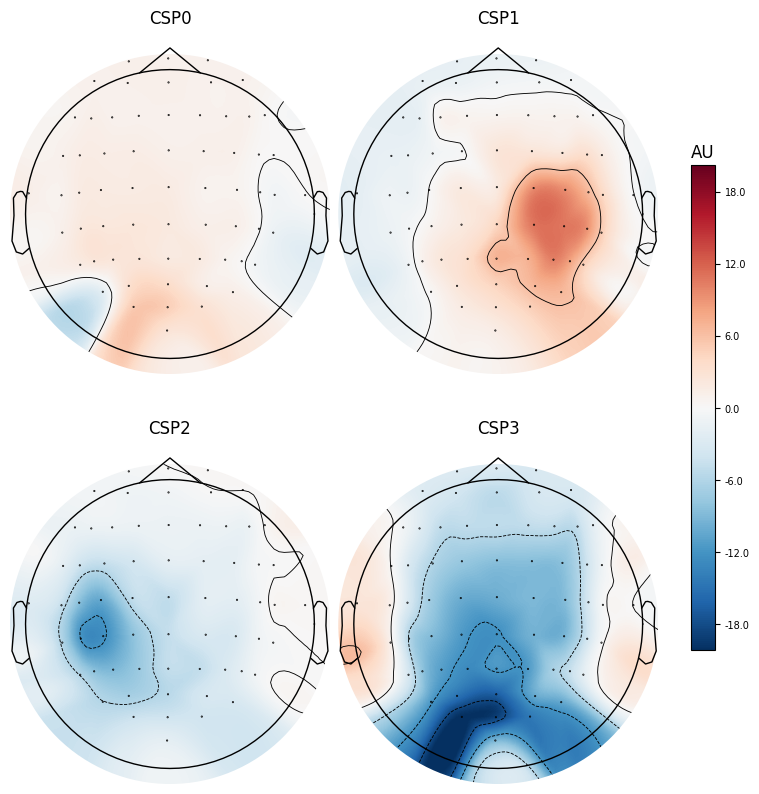

Saved topographic maps to: ../figures/part2/s007_csp_topographic_maps.png


In [33]:
# Pick a representative subject near the median
median_acc = subject_summary_lda_df["mean_loso_accuracy"].median()

rep_row = subject_summary_lda_df.sort_values(
    "mean_loso_accuracy", ascending=False
).iloc[1]

REP_SUBJECT = rep_row["subject_id"]
REP_SUBJECT_ACC = rep_row["mean_loso_accuracy"]

print("Representative subject:", REP_SUBJECT)
print("Representative subject mean LOSO accuracy:", round(REP_SUBJECT_ACC, 4))

# Build this subject's epochs
epochs_rep = build_subject_loso_epochs(
    subject_id=REP_SUBJECT,
    data_dir=DATA_DIR,
    runs=(4, 8, 12),
    l_freq=L_FREQ,
    h_freq=H_FREQ,
    tmin_epoch=EPOCH_TMIN,
    tmax_epoch=EPOCH_TMAX,
    baseline=EPOCH_BASELINE,
)

# Crop to the classifier window
epochs_rep_clf = epochs_rep.copy().crop(
    tmin=CLASSIFIER_TMIN,
    tmax=CLASSIFIER_TMAX,
)

X_rep = epochs_rep_clf.get_data()
meta_rep = epochs_rep_clf.metadata.copy()
y_rep = np.where(meta_rep["label_name"].values == "left", 0, 1)

print("Representative subject cropped shape:", X_rep.shape)
print("Left trials:", int((y_rep == 0).sum()))
print("Right trials:", int((y_rep == 1).sum()))

# Fit CSP on all trials of this subject (visualization only, not evaluation)
csp_topo = CSP(
    n_components=4,
    reg=None,
    log=True,
    norm_trace=False,
)
csp_topo.fit(X_rep, y_rep)

# Plot CSP spatial patterns
fig_patterns = csp_topo.plot_patterns(
    epochs_rep_clf.info,
    components=[0, 1, 2, 3],
    ch_type="eeg",
    units="AU",
    size=2.5,
    nrows=2,
    ncols=2,
    show=False,
)

plt.show()

# Save figure
topo_save_path = FIGURES_DIR / f"{REP_SUBJECT.lower()}_csp_topographic_maps.png"
fig_patterns.savefig(topo_save_path, dpi=300, bbox_inches="tight")
print(f"Saved topographic maps to: {topo_save_path}")

`Notes`:

These maps show the spatial patterns learned by CSP for one high-performing illustrative subject. These are interpreted as **discriminative spatial patterns**, not as direct brain activation maps.

The colorbar is shown in **AU (Arbitrary Units)** because CSP patterns are learned spatial weights, not raw EEG voltages.

This means the map region with:
- larger positive or negative values indicate stronger contribution of that component in that scalp region,
- values near zero indicate weaker contribution.

Main observations:
- **CSP1 and CSP2** appear to form the clearest discriminative pair because they show stronger structure over central scalp regions.
- **CSP0 and CSP3** are more diffuse and are less directly interpretable as the main motor imagery patterns.

In [34]:
# Transform the representative subject data with the fitted CSP
X_rep_csp = csp_topo.transform(X_rep)

# Table of CSP features by class
csp_feature_df = pd.DataFrame(
    X_rep_csp,
    columns=[f"CSP{i}" for i in range(X_rep_csp.shape[1])]
)
csp_feature_df["label"] = np.where(y_rep == 0, "left", "right")

# Mean log-variance per class for each component
class_means = csp_feature_df.groupby("label").mean().T
class_means["favours"] = np.where(
    class_means["left"] > class_means["right"],
    "left",
    "right"
)

class_means

label,left,right,favours
CSP0,-1.652689,-1.067651,right
CSP1,-1.496010,-0.366160,right
CSP2,-0.326390,-1.469521,left
CSP3,-1.206834,-0.467331,right


`Notes`:  
- The components are not labeled as left or right purely from the topography itself. Instead, the class association was determined by comparing the mean CSP feature values for left vs right trials.

## Overall Confusion Matrices for Baseline LDA and SVM

In [35]:
def confusion_matrix_from_fold_csv(csv_path: Path):
    """
    Build aggregated 2x2 confusion matrix from saved fold-level results.
    
    Matrix layout:
        [[TN_left_correct, FP_left_as_right],
         [FN_right_as_left, TP_right_correct]]
    """
    df = pd.read_csv(csv_path)

    cm = np.array([
        [
            df["tn_left_correct"].sum(),
            df["fp_left_as_right"].sum(),
        ],
        [
            df["fn_right_as_left"].sum(),
            df["tp_right_correct"].sum(),
        ],
    ], dtype=int)

    return df, cm


def metrics_from_confusion_matrix(cm):
    """
    Compute precision/recall/F1/support for left and right classes
    from a 2x2 confusion matrix.
    
    cm layout:
        [[TN_left_correct, FP_left_as_right],
         [FN_right_as_left, TP_right_correct]]
    """
    tn, fp = cm[0, 0], cm[0, 1]
    fn, tp = cm[1, 0], cm[1, 1]

    # Treat "left" as class 0
    left_support = tn + fp
    left_precision = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    left_recall = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    left_f1 = (
        2 * left_precision * left_recall / (left_precision + left_recall)
        if (left_precision + left_recall) > 0 else 0.0
    )

    # Treat "right" as class 1
    right_support = fn + tp
    right_precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    right_recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    right_f1 = (
        2 * right_precision * right_recall / (right_precision + right_recall)
        if (right_precision + right_recall) > 0 else 0.0
    )

    total = cm.sum()
    accuracy = (tn + tp) / total if total > 0 else 0.0

    macro_precision = (left_precision + right_precision) / 2
    macro_recall = (left_recall + right_recall) / 2
    macro_f1 = (left_f1 + right_f1) / 2

    weighted_precision = (
        (left_precision * left_support + right_precision * right_support) / total
        if total > 0 else 0.0
    )
    weighted_recall = (
        (left_recall * left_support + right_recall * right_support) / total
        if total > 0 else 0.0
    )
    weighted_f1 = (
        (left_f1 * left_support + right_f1 * right_support) / total
        if total > 0 else 0.0
    )

    metrics_df = pd.DataFrame({
        "class": ["left", "right", "accuracy", "macro avg", "weighted avg"],
        "precision": [
            left_precision, right_precision, np.nan, macro_precision, weighted_precision
        ],
        "recall": [
            left_recall, right_recall, np.nan, macro_recall, weighted_recall
        ],
        "f1-score": [
            left_f1, right_f1, np.nan, macro_f1, weighted_f1
        ],
        "support": [
            left_support, right_support, total, total, total
        ],
        "accuracy": [
            np.nan, np.nan, accuracy, np.nan, np.nan
        ]
    })

    return metrics_df


def plot_confusion_matrix(cm, title: str, save_path: Path):
    fig, ax = plt.subplots(figsize=(5, 4))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["left", "right"],
    )
    disp.plot(ax=ax, colorbar=False)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved confusion matrix to: {save_path}")

LDA aggregated confusion matrix:
[[1465  931]
 [ 895 1457]]


,class,precision,recall,f1-score,support,accuracy
0,left,0.620763,0.611436,0.616064,2396,NaN
1,right,0.610134,0.619473,0.614768,2352,NaN
2,accuracy,NaN,NaN,NaN,4748,0.615417
3,macro avg,0.615448,0.615454,0.615416,4748,NaN
4,weighted avg,0.615498,0.615417,0.615422,4748,NaN


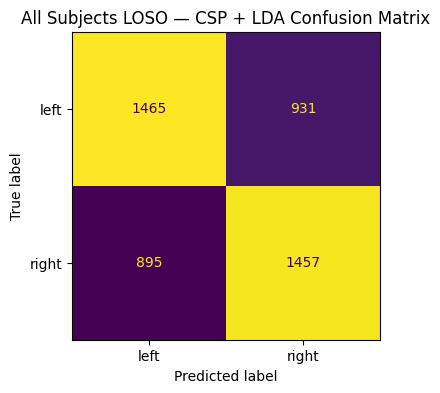

Saved confusion matrix to: ../figures/part2/lda_baseline_all_subjects_loso_confusion_matrix.png


In [36]:
lda_folds_path = BASELINE_RESULTS_DIR / "all_subjects_loso_lda_folds.csv"

lda_folds_df, lda_cm = confusion_matrix_from_fold_csv(lda_folds_path)
lda_metrics_df = metrics_from_confusion_matrix(lda_cm)

print("LDA aggregated confusion matrix:")
print(lda_cm)
display(lda_metrics_df)

plot_confusion_matrix(
    lda_cm,
    title="All Subjects LOSO — CSP + LDA Confusion Matrix",
    save_path=FIGURES_DIR / "lda_baseline_all_subjects_loso_confusion_matrix.png",
)

lda_metrics_df.to_csv(
    BASELINE_RESULTS_DIR / "lda_baseline_all_subjects_loso_classification_report.csv",
    index=False,
)

SVM aggregated confusion matrix:
[[1451  945]
 [ 874 1478]]


,class,precision,recall,f1-score,support,accuracy
0,left,0.624086,0.605593,0.614700,2396,NaN
1,right,0.609988,0.628401,0.619058,2352,NaN
2,accuracy,NaN,NaN,NaN,4748,0.616891
3,macro avg,0.617037,0.616997,0.616879,4748,NaN
4,weighted avg,0.617102,0.616891,0.616859,4748,NaN


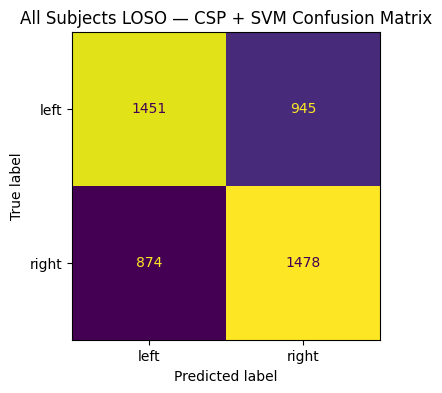

Saved confusion matrix to: ../figures/part2/svm_baseline_all_subjects_loso_confusion_matrix.png


In [37]:
svm_folds_path = BASELINE_RESULTS_DIR / "all_subjects_loso_svm_folds.csv"

svm_folds_df, svm_cm = confusion_matrix_from_fold_csv(svm_folds_path)
svm_metrics_df = metrics_from_confusion_matrix(svm_cm)

print("SVM aggregated confusion matrix:")
print(svm_cm)
display(svm_metrics_df)

plot_confusion_matrix(
    svm_cm,
    title="All Subjects LOSO — CSP + SVM Confusion Matrix",
    save_path=FIGURES_DIR / "svm_baseline_all_subjects_loso_confusion_matrix.png",
)

svm_metrics_df.to_csv(
    BASELINE_RESULTS_DIR / "svm_baseline_all_subjects_loso_classification_report.csv",
    index=False,
)

## Hyper-prarameter tuning

In [38]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.part2.config import (
    N_COMPONENTS_SET,
    SOLVER_SET,
    SHRINKAGE_SET,
    SVM_KERNEL_SET,
    SVM_C_SET
)

from src.part2.experiment_tracking import (
    RESULTS_DIR as TUNING_RESULTS_DIR,
    make_config_id,
    append_rows_csv,
    compute_fold_metrics,
    summarize_experiments,
)

print("Project root:", PROJECT_ROOT)
print("Tuning results dir:", TUNING_RESULTS_DIR)

Project root: /Users/neehanth/Documents/AI R&D Intern/assignments/EEG_Signal_Processing_Classification/eeg_signal_processing_classification
Tuning results dir: /Users/neehanth/Documents/AI R&D Intern/assignments/EEG_Signal_Processing_Classification/eeg_signal_processing_classification/results/part2/tuning


In [39]:
# Config list
from itertools import product

lda_configs = []

for n_components, solver in product(N_COMPONENTS_SET, SOLVER_SET):
    if solver == "svd":
        lda_configs.append({
            "model_name": "LDA",
            "n_components": n_components,
            "lda_solver": solver,
            "lda_shrinkage": None,
            "svm_kernel": None,
            "svm_c": None,
        })
    else:
        for shrinkage in SHRINKAGE_SET:
            lda_configs.append({
                "model_name": "LDA",
                "n_components": n_components,
                "lda_solver": solver,
                "lda_shrinkage": shrinkage,
                "svm_kernel": None,
                "svm_c": None,
            })

svm_configs = [
    {
        "model_name": "SVM",
        "n_components": n_components,
        "lda_solver": None,
        "lda_shrinkage": None,
        "svm_kernel": kernel,
        "svm_c": c,
    }
    for n_components, kernel, c in product(N_COMPONENTS_SET, SVM_KERNEL_SET, SVM_C_SET)
]

# Save config catalogs
lda_catalog_df = pd.DataFrame(
    [{"config_id": make_config_id(cfg), **cfg} for cfg in lda_configs]
).sort_values(["n_components", "lda_solver", "lda_shrinkage"], na_position="last")

svm_catalog_df = pd.DataFrame(
    [{"config_id": make_config_id(cfg), **cfg} for cfg in svm_configs]
).sort_values(["n_components", "svm_kernel", "svm_c"], na_position="last")

print(f"LDA configs: {len(lda_configs)}")
display(lda_catalog_df.head())

print(f"SVM configs: {len(svm_configs)}")
display(svm_catalog_df.head())

LDA configs: 36


,config_id,model_name,n_components,lda_solver,lda_shrinkage,svm_kernel,svm_c
7,dc8c5d4d9a,LDA,2,eigen,0.1,None,None
8,027946b30f,LDA,2,eigen,0.3,None,None
6,4784f644d1,LDA,2,eigen,auto,None,None
5,8084c93394,LDA,2,eigen,None,None,None
3,19e9ab93ec,LDA,2,lsqr,0.1,None,None


SVM configs: 20


,config_id,model_name,n_components,lda_solver,lda_shrinkage,svm_kernel,svm_c
0,8740b3428c,SVM,2,None,None,linear,0.01
1,105b62ab8a,SVM,2,None,None,linear,0.10
2,78ff512e63,SVM,2,None,None,linear,1.00
3,b3e1e9c8b7,SVM,2,None,None,linear,10.00
4,99165048a3,SVM,2,None,None,linear,100.00


In [48]:
from src.part2.model_factory import make_classifier_from_config
from src.part2.tuning_eval import evaluate_subject_loso_for_config
from typing import Any, Dict, List
import json

def run_tuning_experiments(
    configs: List[Dict[str, Any]],
    experiment_group: str,
    subject_ids: List[str],
    clf_tmin: float,
    clf_tmax: float,
    overwrite: bool = True,
):
    run_dir = TUNING_RESULTS_DIR / experiment_group
    run_dir.mkdir(parents=True, exist_ok=True)

    config_catalog_path = run_dir / "config_catalog.csv"
    fold_results_path = run_dir / "fold_results.csv"
    failures_path = run_dir / "subject_failures.csv"
    summary_path = run_dir / "experiments_summary.csv"
    best_config_path = run_dir / "best_config.json"

    if overwrite:
        for path in [config_catalog_path, fold_results_path, failures_path, summary_path, best_config_path]:
            if path.exists():
                path.unlink()

    catalog_df = pd.DataFrame(
        [{"config_id": make_config_id(cfg), **cfg} for cfg in configs]
    )
    catalog_df.to_csv(config_catalog_path, index=False)

    print(f"\n=== Running {experiment_group} ===")
    print(f"Configs: {len(configs)}")
    print(f"Subjects: {len(subject_ids)}")

    for config_idx, config in enumerate(configs, start=1):
        config_id = make_config_id(config)
        config_fold_rows = []
        config_fail_rows = []

        for subject_idx, subject_id in enumerate(subject_ids, start=1):
            try:
                epochs_subject = build_subject_loso_epochs(
                    subject_id=subject_id,
                    data_dir=DATA_DIR,
                    runs=(4, 8, 12),
                    l_freq=L_FREQ,
                    h_freq=H_FREQ,
                    tmin_epoch=EPOCH_TMIN,
                    tmax_epoch=EPOCH_TMAX,
                    baseline=EPOCH_BASELINE,
                )

                rows = evaluate_subject_loso_for_config(
                    subject_id=subject_id,
                    epochs_subject_loso=epochs_subject,
                    config=config,
                    experiment_group=experiment_group,
                    clf_tmin=clf_tmin,
                    clf_tmax=clf_tmax,
                )
                config_fold_rows.extend(rows)
                if subject_idx % 10 == 0 or subject_idx == len(subject_ids):
                    print(
                        f"  -> config {config_idx:02d}/{len(configs):02d} | "
                        f"subject {subject_idx:03d}/{len(subject_ids):03d} ({subject_id}) | "
                        f"latest_subj_acc={np.mean([r['accuracy'] for r in rows]):.3f} | "
                        f"running_bal_acc={pd.DataFrame(config_fold_rows)['balanced_accuracy'].mean():.3f}"
                    )

            except Exception as e:
                config_fail_rows.append({
                    "experiment_group": experiment_group,
                    "config_id": config_id,
                    "model_name": config["model_name"],
                    "subject_id": subject_id,
                    "n_components": config.get("n_components"),
                    "lda_solver": config.get("lda_solver"),
                    "lda_shrinkage": config.get("lda_shrinkage"),
                    "svm_kernel": config.get("svm_kernel"),
                    "svm_c": config.get("svm_c"),
                    "error": str(e),
                })

        append_rows_csv(fold_results_path, config_fold_rows)
        append_rows_csv(failures_path, config_fail_rows)

        config_fold_df = pd.DataFrame(config_fold_rows)
        if not config_fold_df.empty:
            mean_acc = config_fold_df["accuracy"].mean()
            mean_bal_acc = config_fold_df["balanced_accuracy"].mean()
            std_acc = config_fold_df["accuracy"].std(ddof=0)
            print(
                f"[{config_idx:02d}/{len(configs):02d}] "
                f"{config['model_name']} | {config_id} | "
                f"bal_acc={mean_bal_acc:.4f} | acc={mean_acc:.4f} | std={std_acc:.4f}"
            )
        else:
            print(
                f"[{config_idx:02d}/{len(configs):02d}] "
                f"{config['model_name']} | {config_id} | no successful folds"
            )

    fold_df = pd.read_csv(fold_results_path) if fold_results_path.exists() else pd.DataFrame()
    summary_df = summarize_experiments(fold_df) if not fold_df.empty else pd.DataFrame()
    summary_df.to_csv(summary_path, index=False)

    failures_df = pd.read_csv(failures_path) if failures_path.exists() else pd.DataFrame()

    if not summary_df.empty:
        best_row = summary_df.sort_values(
            by=["mean_balanced_accuracy", "mean_accuracy", "std_accuracy"],
            ascending=[False, False, True],
        ).iloc[0]

        best_config_id = best_row["config_id"]
        best_config = next(cfg for cfg in configs if make_config_id(cfg) == best_config_id)

        best_payload = {
            "experiment_group": experiment_group,
            "best_config_id": best_config_id,
            "best_config": best_config,
            "best_metrics": best_row.to_dict(),
        }

        with open(best_config_path, "w") as f:
            json.dump(best_payload, f, indent=2, default=str)

    print(f"\nSaved: {run_dir}")
    print(f"Fold rows   : {len(fold_df)}")
    print(f"Failures    : {len(failures_df)}")
    print(f"Summary rows: {len(summary_df)}")

    return fold_df, summary_df, failures_df, run_dir

In [49]:
# LDA tuning
lda_fold_df, lda_summary_df, lda_failures_df, lda_run_dir = run_tuning_experiments(
    configs=lda_configs,
    experiment_group="lda_tuning_v1",
    subject_ids=CLEAN_SUBJECTS,
    clf_tmin=CLASSIFIER_TMIN,
    clf_tmax=CLASSIFIER_TMAX,
    overwrite=True,
)

display(lda_summary_df.head(10))

if not lda_failures_df.empty:
    display(lda_failures_df.head())


=== Running lda_tuning_v1 ===
Configs: 36
Subjects: 106
  -> config 01/36 | subject 010/106 (S010) | latest_subj_acc=0.533 | running_bal_acc=0.578
  -> config 01/36 | subject 020/106 (S020) | latest_subj_acc=0.533 | running_bal_acc=0.584
  -> config 01/36 | subject 030/106 (S030) | latest_subj_acc=0.400 | running_bal_acc=0.582
  -> config 01/36 | subject 040/106 (S040) | latest_subj_acc=0.533 | running_bal_acc=0.599
  -> config 01/36 | subject 050/106 (S050) | latest_subj_acc=0.689 | running_bal_acc=0.595
  -> config 01/36 | subject 060/106 (S060) | latest_subj_acc=0.867 | running_bal_acc=0.609
  -> config 01/36 | subject 070/106 (S070) | latest_subj_acc=0.533 | running_bal_acc=0.607
  -> config 01/36 | subject 080/106 (S080) | latest_subj_acc=0.667 | running_bal_acc=0.604
  -> config 01/36 | subject 090/106 (S091) | latest_subj_acc=0.511 | running_bal_acc=0.608
  -> config 01/36 | subject 100/106 (S103) | latest_subj_acc=0.400 | running_bal_acc=0.605
  -> config 01/36 | subject 106/1

,experiment_group,config_id,model_name,n_components,lda_solver,lda_shrinkage,svm_kernel,svm_c,n_subjects,n_folds,mean_accuracy,std_accuracy,mean_balanced_accuracy,std_balanced_accuracy,mean_f1_macro,std_f1_macro,mean_tpr_left,mean_tpr_right
6,lda_tuning_v1,2601698d9c,LDA,6,lsqr,0.3,NaN,NaN,106,318,0.627216,0.159952,0.627059,0.159338,0.588103,0.190822,0.622024,0.632094
29,lda_tuning_v1,ccc9055f10,LDA,6,eigen,0.3,NaN,NaN,106,318,0.627216,0.159952,0.627059,0.159338,0.588103,0.190822,0.622024,0.632094
24,lda_tuning_v1,90f0279793,LDA,8,eigen,0.3,NaN,NaN,106,318,0.623772,0.162898,0.623718,0.162628,0.584928,0.191357,0.621799,0.625636
31,lda_tuning_v1,d93569f381,LDA,8,lsqr,0.3,NaN,NaN,106,318,0.623772,0.162898,0.623718,0.162628,0.584928,0.191357,0.621799,0.625636
2,lda_tuning_v1,0838365997,LDA,6,lsqr,auto,NaN,NaN,106,318,0.623300,0.157050,0.622604,0.156772,0.583730,0.188252,0.619890,0.625318
12,lda_tuning_v1,4b8423888a,LDA,6,eigen,auto,NaN,NaN,106,318,0.623300,0.157050,0.622604,0.156772,0.583730,0.188252,0.619890,0.625318
18,lda_tuning_v1,6f6fd93d83,LDA,4,lsqr,0.3,NaN,NaN,106,318,0.620410,0.160062,0.620639,0.159774,0.579488,0.191290,0.614462,0.626816
20,lda_tuning_v1,7991e5d04f,LDA,4,eigen,0.3,NaN,NaN,106,318,0.620410,0.160062,0.620639,0.159774,0.579488,0.191290,0.614462,0.626816
14,lda_tuning_v1,595b6be87a,LDA,6,eigen,0.1,NaN,NaN,106,318,0.620762,0.159188,0.620320,0.158466,0.582638,0.187715,0.619048,0.621593
33,lda_tuning_v1,f951873acb,LDA,6,lsqr,0.1,NaN,NaN,106,318,0.620762,0.159188,0.620320,0.158466,0.582638,0.187715,0.619048,0.621593


In [50]:
# SVM tuning
svm_fold_df, svm_summary_df, svm_failures_df, svm_run_dir = run_tuning_experiments(
    configs=svm_configs,
    experiment_group="svm_tuning_v1",
    subject_ids=CLEAN_SUBJECTS,
    clf_tmin=CLASSIFIER_TMIN,
    clf_tmax=CLASSIFIER_TMAX,
    overwrite=True,
)

display(svm_summary_df.head(10))

if not svm_failures_df.empty:
    display(svm_failures_df.head())


=== Running svm_tuning_v1 ===
Configs: 20
Subjects: 106
  -> config 01/20 | subject 010/106 (S010) | latest_subj_acc=0.533 | running_bal_acc=0.538
  -> config 01/20 | subject 020/106 (S020) | latest_subj_acc=0.489 | running_bal_acc=0.532
  -> config 01/20 | subject 030/106 (S030) | latest_subj_acc=0.533 | running_bal_acc=0.534
  -> config 01/20 | subject 040/106 (S040) | latest_subj_acc=0.533 | running_bal_acc=0.544
  -> config 01/20 | subject 050/106 (S050) | latest_subj_acc=0.533 | running_bal_acc=0.547
  -> config 01/20 | subject 060/106 (S060) | latest_subj_acc=0.733 | running_bal_acc=0.551
  -> config 01/20 | subject 070/106 (S070) | latest_subj_acc=0.533 | running_bal_acc=0.551
  -> config 01/20 | subject 080/106 (S080) | latest_subj_acc=0.533 | running_bal_acc=0.548
  -> config 01/20 | subject 090/106 (S091) | latest_subj_acc=0.467 | running_bal_acc=0.550
  -> config 01/20 | subject 100/106 (S103) | latest_subj_acc=0.467 | running_bal_acc=0.549
  -> config 01/20 | subject 106/1

,experiment_group,config_id,model_name,n_components,lda_solver,lda_shrinkage,svm_kernel,svm_c,n_subjects,n_folds,mean_accuracy,std_accuracy,mean_balanced_accuracy,std_balanced_accuracy,mean_f1_macro,std_f1_macro,mean_tpr_left,mean_tpr_right
19,svm_tuning_v1,f48b2bda91,SVM,8,NaN,NaN,linear,1.0,106,318,0.624004,0.159042,0.624429,0.158143,0.584680,0.188162,0.611186,0.637672
14,svm_tuning_v1,c051956e09,SVM,6,NaN,NaN,linear,1.0,106,318,0.623750,0.159871,0.623924,0.158807,0.582260,0.189757,0.610231,0.637616
2,svm_tuning_v1,1f6cc013cd,SVM,6,NaN,NaN,linear,100.0,106,318,0.617505,0.157629,0.617157,0.156178,0.572933,0.191201,0.615061,0.619254
18,svm_tuning_v1,f17fd14a01,SVM,4,NaN,NaN,linear,1.0,106,318,0.616801,0.158115,0.617017,0.157680,0.573041,0.190946,0.605645,0.628388
5,svm_tuning_v1,6f8e7933b2,SVM,4,NaN,NaN,linear,100.0,106,318,0.616128,0.156813,0.616989,0.155434,0.573825,0.188057,0.612833,0.621144
3,svm_tuning_v1,298005eb04,SVM,8,NaN,NaN,linear,0.1,106,318,0.616869,0.164649,0.616783,0.163893,0.570485,0.197998,0.605589,0.627976
17,svm_tuning_v1,f004101fef,SVM,6,NaN,NaN,linear,10.0,106,318,0.615544,0.159304,0.615529,0.157745,0.572017,0.191643,0.612197,0.618860
8,svm_tuning_v1,939e306f2c,SVM,6,NaN,NaN,linear,0.1,106,318,0.615851,0.163277,0.615313,0.162416,0.565947,0.199571,0.611897,0.618729
15,svm_tuning_v1,c2b726d4c9,SVM,8,NaN,NaN,linear,10.0,106,318,0.614802,0.167369,0.614724,0.166330,0.570061,0.200431,0.613769,0.615678
13,svm_tuning_v1,bc1f4b810e,SVM,4,NaN,NaN,linear,10.0,106,318,0.613163,0.161503,0.613788,0.160505,0.570686,0.192639,0.608341,0.619235
